In [33]:
# 1. Fetch Source Bids
import os
import sys
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import pytz

import dash
from dash import dcc, html, Input, Output, State, callback, dash_table
import dash_bootstrap_components as dbc
from dash.dash_table.Format import Format, Scheme, Sign, Symbol
from dash.exceptions import PreventUpdate
import plotly.graph_objects as go

sys.path.append("/var/www/python/Prod/nighthawk/")

from nighthawk.util import connections, sql_functions
from nighthawk.data.product.ve import DailyBidsManager
from nighthawk.data.network.node import Node
from nighthawk.viz.giraffe.common_functions import (get_fig, FCC_card, create_title_row, layout_style,
    FCC_datePickerSingle, FCC_input, FCC_dropdown, FCC_button,
    get_callbackFunction_page_usage_counter
)

# Get DA price

In [34]:
#!/usr/bin/env python3
"""
SPP Day-Ahead LMP download and processing pipeline (pure Python).

Replaces the PHP flow in SPP_download_DART_LMP.php when mode=da:
  1. Read DA LMP CSVs from SPP FTP in memory (pd.read_csv), process to dataframe.
  2. Merge with node list, upload to spp_lmp.settlement_location_da_hourly via sql_functions.
  3. Update node list (spp_core.spp_settlement_location_node_list) for new settlement locations.
  4. Optionally find (dt, hr) missing in last lookback_days and repopulate by re-downloading those dates.
  5. Update VE clear_price from DA and allocate cleared MW.
  6. Update LMP summary tables (daily, monthly, quarterly, annual for DA and RT last-30-days).

Calling:
  python3 spp_dataDownload_da_lmp.py [start_dt] [end_dt] [lookback_days]
  start_dt, end_dt: optional; date range to download (default: next calendar day).
  lookback_days: optional; days to check for missing (dt, hr) and repopulate (default 7; 0 = skip gap fill).
"""

from __future__ import print_function

import sys
import random
import ftplib
from datetime import datetime, timedelta
from io import BytesIO

import pandas as pd
import pytz

sys.path.append("/var/www/python/Prod/nighthawk/")
from nighthawk.util import sql_functions, dataframe_functions

sys.path.append("/var/www/python/Prod/COMMON/monitoring/notification_system/")
from send_msg_through_slack import send_msg_through_slack

sys.path.append("/var/www/python/Prod/SPP/DataDownload/LMP/")
from spp_update_lmp_summary import run_cron_job_summaries

# Config
FTP_HOST = 'pubftp-mte.itespp.org'
FTP_BASE = '/Markets/DA/LMP_By_SETTLEMENT_LOC'
# Per-day file path under FTP_BASE: YYYY/MM/By_Day/DA-LMP-SL-YYYYMMDD0100.csv
TZ = pytz.timezone('America/Chicago')

LMP_TABLE = 'spp_temp.settlement_location_da_hourly_mte'
NODE_LIST_TABLE = 'spp_core.spp_settlement_location_node_list'
MIN_ROWS_QC = 100  # skip file if too few valid rows
BAA_CSV_COL = 'BAA'  # optional column; present once SPP adds it to the data source
script_name = 'spp_dataDownload_da_lmp.py'
warning_string = ''


def _csv_to_dataframe(io_or_path, source=None):
    """Parse one DA LMP CSV (file-like or path) into a dataframe with dt, hr, settlement_location, da_value, marginalloss_value, congestional_value."""
    df = pd.read_csv(io_or_path)
    df.columns = df.columns.str.strip()
    df = df[df['Settlement Location'].notna() & df['Interval'].notna()].copy()
    df['Interval'] = pd.to_datetime(df['Interval'], errors='coerce')
    df = df[df['Interval'].dt.year > 2000].copy()
    if df.empty:
        return df
    # DA rule: Interval - 1 hour -> dt (date) and hr 1-24 (midnight -> previous day, hr 24)
    shifted = df['Interval'] - pd.Timedelta(hours=1)
    df['dt'] = shifted.dt.strftime('%Y-%m-%d')
    df['hr'] = shifted.dt.hour + 1
    df['settlement_location'] = df['Settlement Location'].astype(str).str.strip()
    df['da_value'] = pd.to_numeric(df['LMP'], errors='coerce').fillna(0).astype(float)
    df['marginalloss_value'] = pd.to_numeric(df['MLC'], errors='coerce').fillna(0).astype(float)
    df['congestional_value'] = pd.to_numeric(df['MCC'], errors='coerce').fillna(0).astype(float)
    cols = ['dt', 'hr', 'settlement_location', 'da_value', 'congestional_value', 'marginalloss_value']
    df['baa_zone'] = df[BAA_CSV_COL].astype(str).str.strip().map({'SPP': 'E', 'SWPW': 'W'}).fillna('SPP')
    cols.append('baa_zone')
    return df[cols]


def fetch_da_lmp_dataframe_from_ftp(start_dt, end_dt):
    """
    Fetch DA LMP CSV for each date in [start_dt, end_dt] from SPP FTP (one file per day:
    .../YYYY/MM/By_Day/DA-LMP-SL-YYYYMMDD0100.csv), read in memory, return one concatenated dataframe.
    """
    start_dt = pd.to_datetime(start_dt).date()
    end_dt = pd.to_datetime(end_dt).date()
    if start_dt > end_dt:
        return pd.DataFrame()

    ftp = ftplib.FTP(FTP_HOST)
    ftp.login('anonymous', 'download')
    frames = []
    for d in pd.date_range(start=start_dt, end=end_dt):
        dt = d.date()
        year, month, day = dt.year, dt.month, dt.day
        file_name = 'DA-LMP-SL-{:04d}{:02d}{:02d}0100.csv'.format(year, month, day)
        remote_dir = '{}/{}/{:02d}/By_Day'.format(FTP_BASE, year, month)
        try:
            ftp.cwd(remote_dir)
            bio = BytesIO()
            ftp.retrbinary('RETR ' + file_name, bio.write)
            bio.seek(0)
            one = _csv_to_dataframe(bio, source=file_name)
            if len(one) >= MIN_ROWS_QC:
                frames.append(one)
                print('Processed {} ({} rows)'.format(file_name, len(one)))
            else:
                print('Skipped {} (too few rows: {})'.format(file_name, len(one)))
        except ftplib.error_perm:
            print('FTP failed {} (By_Day dir)'.format(file_name))
        except Exception as e:
            print('Failed {}: {}'.format(file_name, e))
    ftp.quit()

    if not frames:
        print('No CSV data loaded.')
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    out = out.drop_duplicates(subset=['dt', 'hr', 'settlement_location'], keep='last')
    print('Total rows: {}'.format(len(out)))
    return out


def update_da_lmp_from_dataframe(df):
    """
    Merge df with node list (from DB), insert new settlement locations into node list,
    then upload LMP dataframe directly to spp_lmp.settlement_location_da_hourly. No temp table.

    If the source data contains a BAA column (parsed as baa_zone), this function also:
      - Updates baa_zone in NODE_LIST_TABLE for existing nodes where the value has changed.
      - Populates baa_zone when inserting new nodes.
    baa_zone is never written to the LMP tables (sl_rt_5_min / settlement_location_*_hourly).
    """
    if df.empty:
        print('No data to update.')
        return

    has_baa = 'baa_zone' in df.columns

    # Get node list from DB
    node_list = sql_functions.download_df_from_sql_db(
        "SELECT node_num, node_name FROM {}".format(NODE_LIST_TABLE)
    )
    df = df.merge(node_list, left_on='settlement_location', right_on='node_name', how='left')
    df = df.drop(columns=['node_name'], errors='ignore')
    # node_num may be NaN for new locations

    # Rows to upload to LMP table (must have node_num)
    lmp_upload = df.loc[df['node_num'].notna() & (df['node_num'] > 0)].copy()
    if lmp_upload.empty:
        print('No rows with node_num to upload.')
        return
    
    #Align columns to the exact order of LMP_TABLE; fill any unexpected missing columns with NaN.
    lmp_table_cols = sql_functions.download_df_from_sql_db(
        "SELECT * FROM {} LIMIT 1".format(LMP_TABLE)
    ).columns.tolist()
    lmp_upload = lmp_upload[lmp_table_cols]
    sql_functions.replace_into_sql_table(lmp_upload, LMP_TABLE)

    print('CSV to DB update done.')


# def update_bid_prices():
#     """Set clear_price from DA LMP for last 7 days."""
#     sql_functions.run_sql_query("""
#         UPDATE odessa_Bid.SPPFinalBids_multipleStrategies c
#         JOIN spp_lmp.settlement_location_da_hourly da
#           ON c.dt = da.dt AND c.hr = da.hr AND c.node_num = da.node_num
#         SET c.clear_price = da.da_value
#         WHERE da.dt > CURRENT_DATE - INTERVAL 35 DAY
#     """)


# def update_bids_table():
#     """
#     Allocate cleared MW to bids; update odessa_Bid.SPPFinalBids_multipleStrategies.
#     Downloads SPPFinalBids_multipleStrategies (last 30 days) and SPPClearBids JOIN node_list and DA LMP,
#     does allocation in Python, uploads (bid_num, clear_mw) to a temp table, then one UPDATE JOIN to final table.
#     """
#     # 1) Download clear bids with node_name and DA price (one query)
#     clear_df = sql_functions.download_df_from_sql_db("""
#         SELECT c.dt, c.hr, c.nodeNum AS node_num, nl.node_name, c.incdec, c.clearMw AS clear_mw
#         FROM odessa_Bid.SPPClearBids c
#         JOIN spp_lmp.settlement_location_da_hourly da
#           ON c.dt = da.dt AND c.hr = da.hr AND c.nodeNum = da.node_num
#         JOIN spp_core.spp_settlement_location_node_list nl ON c.nodeNum = nl.node_num
#         WHERE c.dt > CURRENT_DATE - INTERVAL 35 DAY AND c.clearMw <> 0
#     """)
#     # 2) Download bids from final table (last 30 days) – columns needed for allocation and for final update
#     bids_df = sql_functions.download_df_from_sql_db("""
#         SELECT bid_num, dt, hr, node_name, incdec, bid_mw, bid_price
#         FROM odessa_Bid.SPPFinalBids_multipleStrategies
#         WHERE dt > CURRENT_DATE - INTERVAL 35 DAY
#     """)
#     if bids_df.empty:
#         print('No bids in last 30 days; skipping bid MW allocation.')
#         return

#     # Normalize dtypes for merging
#     bids_df['dt'] = pd.to_datetime(bids_df['dt']).dt.strftime('%Y-%m-%d')
#     if not clear_df.empty:
#         clear_df['dt'] = pd.to_datetime(clear_df['dt']).dt.strftime('%Y-%m-%d')

#     # 3) Allocation in Python: start with clear_mw = 0 for every bid_num
#     clear_mw_by_bid = dict(zip(bids_df['bid_num'], [0.0] * len(bids_df)))
#     bids_with_mw = bids_df[bids_df['bid_mw'] > 0].copy()

#     for _, r in clear_df.iterrows():
#         dt, hr, node_name, incdec, clear_mw = (
#             r['dt'], int(r['hr']), r['node_name'], r['incdec'], float(r['clear_mw'])
#         )
#         match = (bids_with_mw['dt'] == dt) & (bids_with_mw['hr'] == hr) & \
#                 (bids_with_mw['node_name'].astype(str) == str(node_name)) & (bids_with_mw['incdec'] == incdec)
#         subset = bids_with_mw.loc[match].copy()
#         if subset.empty:
#             continue
#         subset = subset.sort_values('bid_price', ascending=(incdec != 'Decrement'))
#         balance_mw = clear_mw
#         n_bids = len(subset)
#         for idx, b in subset.iterrows():
#             if abs(balance_mw) <= 0.01:
#                 break
#             bid_num, bid_mw = b['bid_num'], float(b['bid_mw'])
#             clear_this = balance_mw if n_bids == 1 else (bid_mw if abs(balance_mw) > bid_mw else balance_mw)
#             clear_mw_by_bid[bid_num] = clear_this
#             balance_mw -= clear_this
#             n_bids -= 1

#     # 4) Build result dataframe: bid_num, clear_mw (all bid_nums in 30-day window)
#     result_df = pd.DataFrame([
#         {'bid_num': bid_num, 'clear_mw': clear_mw_by_bid.get(bid_num, 0.0)}
#         for bid_num in bids_df['bid_num'].unique()
#     ])
#     result_df = result_df.dropna(subset=['bid_num'])

#     # 5) Upload (bid_num, clear_mw) to temp table, then one UPDATE JOIN to final table
#     t_temp_name = 'SPPFinalBids_clear_mw_{}'.format(random.randint(10000, 99999))
#     t_temp = 'temp.{}'.format(t_temp_name)
#     sql_functions.upload_to_sql_from_dataframe(
#         result_df[['bid_num', 'clear_mw']],
#         table_name=t_temp_name,
#         dataset_name='temp',
#     )
#     sql_functions.run_sql_query("""
#         UPDATE odessa_Bid.SPPFinalBids_multipleStrategies b
#         JOIN {} t ON b.bid_num = t.bid_num
#         SET b.clear_mw = t.clear_mw
#     """.format(t_temp))
#     sql_functions.run_sql_query("DROP TABLE IF EXISTS {}".format(t_temp))
#     print('Bid MW allocation done.')


def main():
    timezone = pytz.timezone('America/Chicago')
    now = datetime.now(timezone)
    next_day = (now + timedelta(days=1)).strftime('%Y-%m-%d')

    try:
        start_dt = pd.to_datetime(sys.argv[1]).strftime('%Y-%m-%d')
    except (IndexError, ValueError):
        start_dt = next_day
    try:
        end_dt = pd.to_datetime(sys.argv[2]).strftime('%Y-%m-%d')
    except (IndexError, ValueError):
        end_dt = start_dt

    lookback_days = 7
    if len(sys.argv) > 3:
        try:
            lookback_days = int(sys.argv[3])
        except ValueError:
            pass

    print('start_dt: {}, end_dt: {}, lookback_days (gap fill): {}'.format(start_dt, end_dt, lookback_days))
    if pd.to_datetime(start_dt) > pd.to_datetime(end_dt):
        print('Start date must be <= end date. Exiting.')
        sys.exit(1)

    print('\nGetting LMP data from FTP (in memory)...')
    df = fetch_da_lmp_dataframe_from_ftp('2026-03-29', '2026-03-29')
    print('done')
    print(df.head())

    if not df.empty:
        print('\nUpdating data in tables...')
        update_da_lmp_from_dataframe(df)
        print('done')


    # print('\nSummarizing daily/monthly/etc tables....')
    # run_cron_job_summaries()

if __name__ == '__main__':
    main()


start_dt: 2026-03-31, end_dt: 2026-03-31, lookback_days (gap fill): 7

Getting LMP data from FTP (in memory)...
Processed DA-LMP-SL-202603290100.csv (37872 rows)
Total rows: 37872
done
           dt  hr settlement_location  da_value  congestional_value  \
0  2026-03-29   1                 AEC   20.3645              1.9700   
1  2026-03-29   1           AECC_CSWS   20.7771              2.3470   
2  2026-03-29   1         AECC_ELKINS   15.8756             -2.2653   
3  2026-03-29   1       AECC_FITZHUGH   20.3773              1.7783   
4  2026-03-29   1       AECC_FLTCREEK   15.4963             -2.4188   

   marginalloss_value baa_zone  
0              0.8071        E  
1              0.8427        E  
2              0.5535        E  
3              1.0115        E  
4              0.3276        E  

Updating data in tables...
CSV to DB update done.
done


# Get RT price

In [35]:
#!/usr/bin/env python3
"""
SPP Real-Time LMP live-interval download and processing pipeline (pure Python).

Replaces the PHP flow in SPP_download_DART_LMP.php when mode=rt:
  1. Fetch RTBM-LMP-SL-latestInterval.csv from SPP FTP in memory.
  2. Parse CSV: Interval - 5 min gives dt/hr (hr 1-24), forecast_time = raw Interval.
  3. Insert new settlement locations into spp_core.spp_settlement_location_node_list.
  4. REPLACE INTO spp_lmp.sl_rt_5_min (resolved node_nums only).
  5. REPLACE INTO spp_lmp.settlement_location_rt_hourly (avg of 5-min for dt/hr/node).
  6. DELETE from sl_rt_5_min rows older than 14 days.
  7. Find specific forecast_time values missing from spp_lmp.sl_rt_5_min in the last
     lookback_hours and re-download exactly those By_Interval files from the SPP FTP.
     e.g. a missing 2026-03-11 00:45:00 → fetches
     /Markets/RTBM/LMP_By_SETTLEMENT_LOC/2026/03/By_Interval/11/RTBM-LMP-SL-202603110045.csv

For backfilling whole historical dates from the By_Day consolidated files (published ~1 week
later), use spp_dataDownload_daily_rt_lmp.py instead.

Calling:
  python3 spp_dataDownload_rt_lmp.py [lookback_hours]
  lookback_hours : optional; hours to scan for missing intervals (default 4; 0 = skip gap fill).
"""

from __future__ import print_function

import sys
import ftplib
from datetime import datetime, timedelta
from io import BytesIO

import pandas as pd
import pytz

sys.path.append("/var/www/python/Prod/nighthawk/")
from nighthawk.util import sql_functions

sys.path.append("/var/www/python/Prod/COMMON/monitoring/notification_system/")
from send_msg_through_slack import send_msg_through_slack

# Config
FTP_HOST     = 'pubftp-mte.itespp.org'
FTP_RT_BASE  = '/Markets/RTBM/LMP_By_SETTLEMENT_LOC'
FTP_RT_LATEST = FTP_RT_BASE + '/RTBM-LMP-SL-latestInterval.csv'
TZ       = pytz.timezone('America/Chicago')

SL_RT_5MIN_TABLE = 'spp_temp.settlement_location_rt_5_min_mte'
RT_HOURLY_TABLE  = 'spp_temp.settlement_location_rt_hourly_mte'
NODE_LIST_TABLE  = 'spp_core.spp_settlement_location_node_list'

BAA_CSV_COL = 'BAA'  # optional column; present once SPP adds it to the data source
baamap = {'SPP':'E','SWPW':"W"}

script_name    = 'spp_dataDownload_rt_lmp.py'
warning_string = ''


def _csv_to_dataframe(io_or_path):
    """Parse one RT LMP interval CSV into a dataframe."""
    df = pd.read_csv(io_or_path)
    df.columns = df.columns.str.strip()
    df = df[df['Settlement Location'].notna() & df['Interval'].notna()].copy()
    df['Interval'] = pd.to_datetime(df['Interval'], errors='coerce')
    df = df[df['Interval'].dt.year > 2000].copy()
    if df.empty:
        return df

    df['forecast_time']      = df['Interval'].dt.strftime('%Y-%m-%d %H:%M:%S')
    shifted                  = df['Interval'] - pd.Timedelta(minutes=5)
    df['dt']                 = shifted.dt.strftime('%Y-%m-%d')
    df['hr']                 = shifted.dt.hour + 1
    df['settlement_location']= df['Settlement Location'].astype(str).str.strip()
    df['rt_value']           = pd.to_numeric(df['LMP'], errors='coerce').fillna(0).astype(float)
    df['marginalloss_value'] = pd.to_numeric(df['MLC'], errors='coerce').fillna(0).astype(float)
    df['congestional_value'] = pd.to_numeric(df['MCC'], errors='coerce').fillna(0).astype(float)
    if 'BAA' in df.columns:
        df['BAA'] = df['BAA'].map(baamap)
    else:
        df['BAA'] = None

    return df[['forecast_time', 'dt', 'hr', 'settlement_location',
               'rt_value', 'marginalloss_value', 'congestional_value','BAA']]


def fetch_rt_lmp_by_date_range(start_dt, end_dt):
    """
    Fetch all RT LMP 5-min interval CSVs for each day in [start_dt, end_dt].

    For each day, lists and downloads every file under:
      /Markets/RTBM/LMP_By_SETTLEMENT_LOC/YYYY/MM/By_Interval/DD/

    Returns one concatenated, deduplicated dataframe sorted by dt/hr/forecast_time.
    """
    start = pd.to_datetime(start_dt).date()
    end   = pd.to_datetime(end_dt).date()

    ftp = ftplib.FTP(FTP_HOST)
    ftp.login('anonymous', 'download')

    frames = []
    for d in pd.date_range(start=start, end=end):
        dt    = d.date()
        year  = '{:04d}'.format(dt.year)
        month = '{:02d}'.format(dt.month)
        day   = '{:02d}'.format(dt.day)
        remote_dir = '{}/{}/{}/By_Interval/{}'.format(FTP_RT_BASE, year, month, day)

        try:
            ftp.cwd(remote_dir)
            files     = ftp.nlst()
            csv_files = sorted(f for f in files if f.endswith('.csv'))
            print('Day {}: found {} files'.format(dt, len(csv_files)))

            for fname in csv_files:
                try:
                    bio = BytesIO()
                    ftp.retrbinary('RETR ' + fname, bio.write)
                    bio.seek(0)
                    one = _csv_to_dataframe(bio)
                    if not one.empty:
                        frames.append(one)
                except Exception as e:
                    print('  Error reading {}: {}'.format(fname, e))

        except ftplib.error_perm:
            print('Directory not found: {}'.format(remote_dir))
        except Exception as e:
            print('Error listing {}: {}'.format(remote_dir, e))

    ftp.quit()

    if not frames:
        print('No data loaded.')
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)
    # out = out.drop_duplicates(subset=['forecast_time', 'settlement_location'], keep='last')
    out = out.sort_values(['dt', 'hr', 'forecast_time', 'settlement_location']).reset_index(drop=True)
    print('Total: {:,} rows from {} interval files'.format(len(out), len(frames)))
    return out




def update_rt_lmp_from_dataframe(df):
    """
    Merge df with node list, then:
      1. INSERT IGNORE INTO spp_lmp.sl_rt_5_min (resolved node_nums only)
      2. REPLACE INTO settlement_location_rt_hourly (avg by dt/hr/node for last 2 days)
      3. DELETE sl_rt_5_min rows older than 7 days

    Note: settlement_location_rt_5_min (RT_5MIN_TABLE) is intentionally not written.
    The PHP flow confirmed it was dead code — the REPLACE INTO that table was commented
    out in download_LMP_from_CSV_to_DB3.php (2016 revision note: "a new, better indexed
    table sl_rt_5_min replaced it"). Only sl_rt_5_min is the live target.
    """
    if df.empty:
        print('No data to update.')
        return

    node_list = sql_functions.download_df_from_sql_db(
        "SELECT node_num, node_name FROM {}".format(NODE_LIST_TABLE)
    )
    df = df.merge(node_list, left_on='settlement_location', right_on='node_name')
    df = df.drop(columns=['node_name'], errors='ignore')
    print(df.columns)

    # sl_rt_5_min: resolved node_nums only (node_num > 0)
    # sl5_table_cols = sql_functions.download_df_from_sql_db(
    #     "SELECT * FROM {} LIMIT 1".format(SL_RT_5MIN_TABLE)
    # ).columns.tolist()
    if not df.empty:
        sql_functions.replace_into_sql_table(df, SL_RT_5MIN_TABLE)
        print('REPLACE INTO {} done ({} rows).'.format(SL_RT_5MIN_TABLE, len(df)))

    sql_functions.run_sql_query("""
        REPLACE INTO {hourly}
        SELECT rt.dt, rt.hr, rt.node_num, BAA,
               AVG(rt.rt_value)           AS rt_value,
               AVG(rt.congestional_value) AS congestional_value,
               AVG(rt.marginalloss_value) AS marginalloss_value
        FROM {sl5} rt
        GROUP BY rt.dt, rt.hr, rt.node_num
    """.format(hourly=RT_HOURLY_TABLE, sl5=SL_RT_5MIN_TABLE))
    print('REPLACE INTO {} (hourly avg) done.'.format(RT_HOURLY_TABLE))

    print('Cleanup of old 5-min rows done.')

    print('RT CSV to DB update done.')



print('\nGetting RT LMP data from FTP (in memory)...')
df = fetch_rt_lmp_by_date_range('2026-03-29','2026-03-29')
if not df.empty:
    print('\nUpdating data in tables...')
    update_rt_lmp_from_dataframe(df)
    print('done')



Getting RT LMP data from FTP (in memory)...
Day 2026-03-29: found 288 files
Total: 454,464 rows from 288 interval files

Updating data in tables...
Index(['forecast_time', 'dt', 'hr', 'settlement_location', 'rt_value',
       'marginalloss_value', 'congestional_value', 'BAA', 'node_num'],
      dtype='object')
REPLACE INTO spp_temp.settlement_location_rt_5_min_mte done (452736 rows).
REPLACE INTO spp_temp.settlement_location_rt_hourly_mte (hourly avg) done.
Cleanup of old 5-min rows done.
RT CSV to DB update done.
done


# Functions to get the bid nodes/ PNL

In [132]:
def simulate_total_ftp(bid_date, sim_end_date,lookback_days, strategy):

    MARKET_CONFIG = {
    'SPP': {
        'load_table': 'spp_physical.spp_latest_load_forecast',
        'wind_table': 'spp_physical.spp_latest_wind_forecast',
        'inc_op_rate': 2.0,
        'dec_op_rate': 0.1
    },
    'PJM': {
        'load_table': '',
        'wind_table': '',
        'inc_op_rate': 0.0,
        'dec_op_rate': 0.0
    },
    'MISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'ERCOT': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'NYISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
}
    
    m_cfg = MARKET_CONFIG['SPP']

    strat_list = [strategy] if (strategy and strategy != 'All') else None
    bid_manager = DailyBidsManager(opexchange='SPP', bid_date=str(bid_date), portfolio=pd.DataFrame())
    df_bids = bid_manager.get_bids_from_table(label='current', strategy_ls=strat_list)
    df_bids.rename(columns={'dt': 'source_dt'}, inplace=True)
    expected_cols = ['source_dt', 'hr', 'node_num', 'node_name', 'bid_mw', 'bid_price', 'incdec', 'strategy']
    df_bids = df_bids[[c for c in expected_cols if c in df_bids.columns]]

    if df_bids.empty:
        return [], [], [], [], get_fig(), {"display": "none"}

    df_bids['hr'] = df_bids['hr'].astype(int)
    df_bids['node_num'] = df_bids['node_num'].astype(int)

    # 2. Date Range & Cross Join
    sim_end_obj = pd.to_datetime(sim_end_date).date()
    target_end_date = sim_end_obj 
    target_start_date = sim_end_obj - timedelta(days=int(lookback_days))

    date_range = pd.date_range(start=target_start_date, end=target_end_date, freq='D')
    df_dates = pd.DataFrame({'sim_dt': date_range})
    df_dates['sim_dt_str'] = df_dates['sim_dt'].dt.strftime('%Y-%m-%d')

    df_dates['key'] = 1
    df_bids['key'] = 1
    df_sim = pd.merge(df_dates, df_bids, on='key').drop('key', axis=1)

    # 3. Prices
    node_list = df_bids['node_num'].unique().tolist()

    node_obj = Node(node_nums=node_list, market='SPP')
    df_prices = node_obj.get_price(
        start_dt=str(target_start_date),
        end_dt=str(target_end_date),
        component=['LMP'],
        type=['DA', 'RT'],
        granularity='hourly'
    )

    if not df_prices.empty:
        df_prices.rename(columns={'da_total': 'dalmp', 'rt_total': 'rtlmp'}, inplace=True)
        df_prices['hr'] = df_prices['hr'].astype(int)
        df_prices['node_num'] = df_prices['node_num'].astype(int)
        df_sim = pd.merge(df_sim, df_prices, left_on=['sim_dt_str', 'hr', 'node_num'],
                            right_on=['dt', 'hr', 'node_num'], how='left')
    else:
        df_sim['dalmp'] = np.nan
        df_sim['rtlmp'] = np.nan

    # 4. Calculations (Preserved as per instruction)
    inc_op_rate = m_cfg['inc_op_rate']
    dec_op_rate = m_cfg['dec_op_rate']

    conditions_clear = [
        (df_sim['incdec'] == 'Decrement') & (df_sim['bid_price'] >= df_sim['dalmp']),
        (df_sim['incdec'] == 'Increment') & (df_sim['bid_price'] <= df_sim['dalmp'])
    ]
    df_sim['is_cleared'] = np.select(conditions_clear, [True, True], default=False)
    df_sim.loc[df_sim['dalmp'].isna(), 'is_cleared'] = False
    df_sim['clear_mw'] = np.where(df_sim['is_cleared'], df_sim['bid_mw'], 0.0)

    # DA & RT Cash
    df_sim['total_da_val'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['dalmp'], df_sim['clear_mw'] * df_sim['dalmp'])
    df_sim['total_da_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_val'])

    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rtlmp'], -1 * df_sim['clear_mw'] * df_sim['rtlmp'])
    df_sim['total_rt_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)

    # RSG
    rsg_cost = np.where(df_sim['incdec'] == 'Increment', df_sim['clear_mw'] * inc_op_rate, df_sim['clear_mw'] * dec_op_rate)
    df_sim['op_rate_val'] = np.where(df_sim['rtlmp'].isna(), 0, -1 * rsg_cost)

    # Totals
    df_sim['gross_pnl'] = df_sim['total_da_elapsed'] + df_sim['total_rt_elapsed']
    df_sim['net_pnl'] = df_sim['gross_pnl'] + df_sim['op_rate_val']
    df_sim.fillna(0, inplace=True)

    # 5. Aggregation & Data Return

    agg_dict = {
        'bid_mw': 'sum', 'clear_mw': 'sum',
        'total_da_val': 'sum', 'total_da_elapsed': 'sum', 'total_rt_elapsed': 'sum', 'op_rate_val': 'sum',
        'gross_pnl': 'sum', 'net_pnl': 'sum'
    }
    renamer = {
        'bid_mw': 'BidMW', 'clear_mw': 'ClearMW',
        'total_da_val': 'TotalDA$', 'total_da_elapsed': 'TotalDAElapsed$',
        'total_rt_elapsed': 'TotalRTElapsed$', 'op_rate_val': 'OpRate$',
        'gross_pnl': 'Gross$', 'net_pnl': 'Net$'
    }

    # A. Overall Summary
    summ_data = df_sim.agg(agg_dict).to_frame().T.rename(columns=renamer).to_dict('records')

    # B. Portfolio Summary
    port_data = df_sim.groupby('strategy').agg(agg_dict).reset_index().rename(columns=renamer).to_dict('records')

    # C. Daily Summary
    daily_df = df_sim.groupby('sim_dt_str').agg(agg_dict).reset_index().rename(columns=renamer)
    daily_df.rename(columns={'sim_dt_str': 'dt'}, inplace=True)
    return df_sim

In [47]:

def simulate_total_mte(bid_date, sim_end_date,lookback_days, strategy):

    MARKET_CONFIG = {
    'SPP': {
        'load_table': 'spp_physical.spp_latest_load_forecast',
        'wind_table': 'spp_physical.spp_latest_wind_forecast',
        'inc_op_rate': 2.0,
        'dec_op_rate': 0.1
    },
    'PJM': {
        'load_table': '',
        'wind_table': '',
        'inc_op_rate': 0.0,
        'dec_op_rate': 0.0
    },
    'MISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'ERCOT': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'NYISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
}
    
    m_cfg = MARKET_CONFIG['SPP']

    strat_list = [strategy] if (strategy and strategy != 'All') else None
    bid_manager = DailyBidsManager(opexchange='SPP', bid_date=str(bid_date), portfolio=pd.DataFrame())
    df_bids = bid_manager.get_bids_from_table(label='current', strategy_ls=strat_list)
    df_bids.rename(columns={'dt': 'source_dt'}, inplace=True)
    expected_cols = ['source_dt', 'hr', 'node_num', 'node_name', 'bid_mw', 'bid_price', 'incdec', 'strategy']
    df_bids = df_bids[[c for c in expected_cols if c in df_bids.columns]]

    if df_bids.empty:
        return [], [], [], [], get_fig(), {"display": "none"}

    df_bids['hr'] = df_bids['hr'].astype(int)
    df_bids['node_num'] = df_bids['node_num'].astype(int)


    # 2. Date Range & Cross Join
    sim_end_obj = pd.to_datetime(sim_end_date).date()
    target_end_date = sim_end_obj
    target_start_date = sim_end_obj - timedelta(days=int(lookback_days))
    # print('simulation start date is ', target_start_date)
    # print('simulation end date is ', target_end_date)

    date_range = pd.date_range(start=target_start_date, end=target_end_date, freq='D')
    df_dates = pd.DataFrame({'sim_dt': date_range})
    df_dates['sim_dt_str'] = df_dates['sim_dt'].dt.strftime('%Y-%m-%d')

    df_dates['key'] = 1
    df_bids['key'] = 1
    df_sim = pd.merge(df_dates, df_bids, on='key').drop('key', axis=1)

    # 3. Prices
    
    da_prices = sql_functions.download_df_from_sql_db(f'''select * from spp_temp.settlement_location_da_hourly_mte where dt>='{target_start_date}' and dt <='{target_end_date}' ''')
    rt_prices = sql_functions.download_df_from_sql_db(f'''select * from spp_temp.settlement_location_rt_hourly_mte where dt>='{target_start_date}' and dt <='{target_end_date}' ''')
    da_prices['da_slack']=da_prices['da_value']-da_prices['congestional_value']-da_prices['marginalloss_value']
    rt_prices['rt_slack']=rt_prices['rt_value']-rt_prices['congestional_value']-rt_prices['marginalloss_value']
    df_prices= pd.merge(da_prices, rt_prices, on=['dt', 'hr', 'node_num'], how='left')



    # select_cols= ['dt','hr','settlement_location','da_value','rt_value','congestional_value','marginalloss_value','node_num']
    # df_prices= df_prices[select_cols]
    if not df_prices.empty:
        df_prices.rename(columns={'da_value': 'dalmp', 'rt_value': 'rtlmp'}, inplace=True)
        df_prices['hr'] = df_prices['hr'].astype(int)
        df_prices['node_num'] = df_prices['node_num'].astype(int)
        df_prices['dt'] = df_prices['dt'].astype(str)
        df_sim = pd.merge(df_sim, df_prices, left_on=['sim_dt_str', 'hr', 'node_num'],
                            right_on=['dt', 'hr', 'node_num'], how='left')
    else:
        df_sim['dalmp'] = np.nan
        df_sim['rtlmp'] = np.nan

    # 4. Calculations (Preserved as per instruction)
    inc_op_rate = m_cfg['inc_op_rate']
    dec_op_rate = m_cfg['dec_op_rate']

    conditions_clear = [
        (df_sim['incdec'] == 'Decrement') & (df_sim['bid_price'] >= df_sim['dalmp']),
        (df_sim['incdec'] == 'Increment') & (df_sim['bid_price'] <= df_sim['dalmp'])
    ]
    df_sim['is_cleared'] = np.select(conditions_clear, [True, True], default=False)
    df_sim.loc[df_sim['dalmp'].isna(), 'is_cleared'] = False
    df_sim['clear_mw'] = np.where(df_sim['is_cleared'], df_sim['bid_mw'], 0.0)

    # DA & RT Cash
    df_sim['total_da_val'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['dalmp'], df_sim['clear_mw'] * df_sim['dalmp'])
    df_sim['total_da_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_val'])
    df_sim['total_da_slack'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['da_slack'], df_sim['clear_mw'] * df_sim['da_slack'])
    df_sim['total_da_slack_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_slack'])
    df_sim['total_da_congestional'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['congestional_value_x'], df_sim['clear_mw'] * df_sim['congestional_value_x'])
    df_sim['total_da_cong_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_congestional'])

    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rtlmp'], -1 * df_sim['clear_mw'] * df_sim['rtlmp'])
    df_sim['total_rt_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rt_slack'], -1 * df_sim['clear_mw'] * df_sim['rt_slack'])
    df_sim['total_rt_slack_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['congestional_value_y'], -1 * df_sim['clear_mw'] * df_sim['congestional_value_y'])
    df_sim['total_rt_cong_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    

    # RSG
    rsg_cost = np.where(df_sim['incdec'] == 'Increment', df_sim['clear_mw'] * inc_op_rate, df_sim['clear_mw'] * dec_op_rate)
    df_sim['op_rate_val'] = np.where(df_sim['rtlmp'].isna(), 0, -1 * rsg_cost)

    # Totals
    df_sim['gross_pnl'] = df_sim['total_da_elapsed'] + df_sim['total_rt_elapsed']
    df_sim['net_pnl'] = df_sim['gross_pnl'] + df_sim['op_rate_val']
    df_sim['slack_pnl'] = df_sim['total_da_slack_elapsed']+df_sim['total_rt_slack_elapsed']
    df_sim['cong_pnl'] = df_sim['total_da_cong_elapsed']+df_sim['total_rt_cong_elapsed']
    
    df_sim.fillna(0, inplace=True)
    df_sim.sort_values(by=['gross_pnl'],ascending=True,inplace=True)


    # 5. Aggregation & Data Return

    agg_dict = {
        'bid_mw': 'sum', 'clear_mw': 'sum',
        'total_da_val': 'sum', 'total_da_elapsed': 'sum', 'total_rt_elapsed': 'sum', 'op_rate_val': 'sum',
        'gross_pnl': 'sum', 'net_pnl': 'sum'
    }
    renamer = {
        'bid_mw': 'BidMW', 'clear_mw': 'ClearMW',
        'total_da_val': 'TotalDA$', 'total_da_elapsed': 'TotalDAElapsed$',
        'total_rt_elapsed': 'TotalRTElapsed$', 'op_rate_val': 'OpRate$',
        'gross_pnl': 'Gross$', 'net_pnl': 'Net$'
    }

    # A. Overall Summary
    summ_data = df_sim.agg(agg_dict).to_frame().T.rename(columns=renamer).to_dict('records')

    # B. Portfolio Summary
    port_data = df_sim.groupby('strategy').agg(agg_dict).reset_index().rename(columns=renamer).to_dict('records')

    # C. Daily Summary
    daily_df = df_sim.groupby('sim_dt_str').agg(agg_dict).reset_index().rename(columns=renamer)
    daily_df.rename(columns={'sim_dt_str': 'dt'}, inplace=True)

    return df_sim

# IncDec PNL

In [213]:
all_results = []

def simulate_dfs(bid_date):
    for i in bid_date:
        dt_str  = pd.Timestamp(i).strftime('%Y-%m-%d')
        sim_end = (pd.Timestamp(i)).strftime('%Y-%m-%d')

        df1 = simulate_total_ftp(dt_str, sim_end, 0, 'Darwin') \
                .groupby(['sim_dt_str', 'incdec']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl'}).reset_index()
        
        df2 = simulate_total_ftp(dt_str, sim_end, 0, 'Fourier') \
                .groupby(['sim_dt_str', 'incdec']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl'}).reset_index()
        
        df3 = simulate_total_mte(dt_str, sim_end, 0, 'Darwin') \
                .groupby(['sim_dt_str', 'incdec']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl', "slack_pnl":'Darwin_slack_pnl',"cong_pnl":'Darwin_cong_pnl'}).reset_index()

        df4 = simulate_total_mte(dt_str, sim_end, 0, 'Fourier') \
                .groupby(['sim_dt_str', 'incdec']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl', "slack_pnl":'Fourier_slack_pnl',"cong_pnl":'Fourier_cong_pnl'}).reset_index()
        
        
        merged = df1.merge(df2, on=['sim_dt_str', 'incdec'], how='outer') \
                    .merge(df3, on=['sim_dt_str', 'incdec'], how='outer') \
                    .merge(df4, on=['sim_dt_str', 'incdec'], how='outer') \
                    .rename(columns={'sim_dt_str': 'dt'})


        print(f"\n{'─'*50}")
        print(f"Bid date: {dt_str}")
        print(merged.to_string(index=False))
        all_results.append(merged)

    return pd.concat(all_results, ignore_index=True)


# ── Run ───────────────────────────────────────────────────────────────────────
start_dt = '2026-03-15'
end_dt   = '2026-03-27'
all_results = []

for i in pd.date_range(start_dt, end_dt):
    simulate_dfs([i])

finals = pd.concat(all_results, ignore_index=True)

# ── Excel ─────────────────────────────────────────────────────────────────────
output_path = '/var/www/python/Qingcheng/simulation_results.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    finals.to_excel(writer, sheet_name='Darwin_vs_Fourier', index=False)

print(f"\nSaved → {output_path}")
display(finals)



──────────────────────────────────────────────────
Bid date: 2026-03-15
        dt    incdec  Darwin_net_pnl_x  Fourier_net_pnl_x  Darwin_net_pnl_y  Darwin_slack_pnl  Darwin_cong_pnl  Fourier_net_pnl_y  Fourier_slack_pnl  Fourier_cong_pnl
2026-03-15 Decrement         14,380.00          10,744.00          7,018.00         15,080.00        -7,719.00          16,632.00          12,249.00          4,630.00
2026-03-15 Increment         14,657.00            -534.00        -37,576.00        -74,769.00        41,223.00        -160,526.00        -213,794.00         51,742.00

──────────────────────────────────────────────────
Bid date: 2026-03-16
        dt    incdec  Darwin_net_pnl_x  Fourier_net_pnl_x  Darwin_net_pnl_y  Darwin_slack_pnl  Darwin_cong_pnl  Fourier_net_pnl_y  Fourier_slack_pnl  Fourier_cong_pnl
2026-03-16 Decrement          2,663.00          13,376.00        129,997.00         89,154.00        40,227.00          77,313.00          79,722.00         -1,539.00
2026-03-16 Incremen

,dt,incdec,Darwin_net_pnl_x,Fourier_net_pnl_x,Darwin_net_pnl_y,Darwin_slack_pnl,Darwin_cong_pnl,Fourier_net_pnl_y,Fourier_slack_pnl,Fourier_cong_pnl
0,2026-03-15,Decrement,"14,380.00","10,744.00","7,018.00","15,080.00","-7,719.00","16,632.00","12,249.00","4,630.00"
1,2026-03-15,Increment,"14,657.00",-534.00,"-37,576.00","-74,769.00","41,223.00","-160,526.00","-213,794.00","51,742.00"
2,2026-03-16,Decrement,"2,663.00","13,376.00","129,997.00","89,154.00","40,227.00","77,313.00","79,722.00","-1,539.00"
3,2026-03-16,Increment,"-6,149.00","-9,506.00","-45,286.00","-41,993.00","-3,766.00","-220,281.00","-345,709.00","111,391.00"
4,2026-03-17,Decrement,"4,776.00","4,245.00",0.00,0.00,0.00,0.00,0.00,0.00
5,2026-03-17,Increment,"10,103.00","22,193.00","100,385.00","103,922.00",242.00,"265,242.00","247,710.00","30,008.00"
6,2026-03-18,Decrement,"-7,242.00","2,606.00","647,479.00","498,240.00","137,688.00","74,734.00","47,047.00","27,303.00"
7,2026-03-18,Increment,"11,230.00","-28,605.00","25,046.00","-13,187.00","39,952.00","-63,580.00","-126,745.00","61,513.00"
8,2026-03-19,Decrement,"-4,604.00","1,333.00","167,962.00","58,709.00","103,521.00","9,301.00","6,220.00","2,601.00"
9,2026-03-19,Increment,"6,604.00","11,827.00","27,576.00","7,595.00","20,669.00","39,059.00","-11,189.00","50,348.00"


# Node_zonal's profit top 5 and bottom 5

In [ ]:

all_results = []

def simulate_dfs(bid_date):
    global df_node
    for i in bid_date:
        dt_str  = pd.Timestamp(i).strftime('%Y-%m-%d')
        sim_end = (pd.Timestamp(i)).strftime('%Y-%m-%d')

        df1 = simulate_total_ftp(dt_str, sim_end, 0, 'Darwin').merge(df_node, on='node_num') \
                .groupby(['sim_dt_str', 'node_zone']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl'}).reset_index()
        
        df2 = simulate_total_ftp(dt_str, sim_end, 0, 'Fourier').merge(df_node, on='node_num') \
                .groupby(['sim_dt_str', 'node_zone']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl'}).reset_index()
        
        df3 = simulate_total_mte(dt_str, sim_end, 0, 'Darwin').merge(df_node, on='node_num')  \
                .groupby(['sim_dt_str', 'node_zone']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl', "slack_pnl":'Darwin_slack_pnl',"cong_pnl":'Darwin_cong_pnl'}).reset_index()

        df4 = simulate_total_mte(dt_str, sim_end, 0, 'Fourier').merge(df_node, on='node_num') \
                .groupby(['sim_dt_str', 'node_zone']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl', "slack_pnl":'Fourier_slack_pnl',"cong_pnl":'Fourier_cong_pnl'}).reset_index()
        
        
        merged = df1.merge(df2, on=['sim_dt_str', 'node_zone'], how='outer') \
                    .merge(df3, on=['sim_dt_str', 'node_zone'], how='outer') \
                    .merge(df4, on=['sim_dt_str', 'node_zone'], how='outer') \
                    .rename(columns={'sim_dt_str': 'dt'})


        print(f"\n{'─'*50}")
        print(f"Bid date: {dt_str}")
        print(merged.to_string(index=False))
        all_results.append(merged)

    return pd.concat(all_results, ignore_index=True)


# ── Run ───────────────────────────────────────────────────────────────────────
start_dt = '2026-03-15'
end_dt   = '2026-03-27'
all_results = []

df_node = sql_functions.download_df_from_sql_db(
    "select node_num, node_name, node_zone "
    "from spp_core.spp_settlement_location_node_list ")
df_node=df_node[['node_num','node_zone']]

for i in pd.date_range(start_dt, end_dt):
    simulate_dfs([i])

finals = pd.concat(all_results, ignore_index=True)

# ── Excel ─────────────────────────────────────────────────────────────────────
output_path = '/var/www/python/Qingcheng/simulation_results_nodezonal.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    finals.to_excel(writer, sheet_name='Darwin_vs_Fourier', index=False)

print(f"\nSaved → {output_path}")


──────────────────────────────────────────────────
Bid date: 2026-03-15
        dt node_zone  Darwin_net_pnl_x  Fourier_net_pnl_x  Darwin_net_pnl_y  Darwin_slack_pnl  Darwin_cong_pnl  Fourier_net_pnl_y  Fourier_slack_pnl  Fourier_cong_pnl
2026-03-15      AECI           -112.00              11.00          1,356.00         -1,737.00         3,135.00          -3,295.00          -6,249.00          3,124.00
2026-03-15      CSWS          1,852.00           2,562.00         11,331.00         -9,478.00        21,271.00          -7,626.00         -43,482.00         34,308.00
2026-03-15       EDE            588.00                NaN         -1,736.00         -3,231.00         1,851.00                NaN                NaN               NaN
2026-03-15    ERCOTE             48.00             164.00              0.00              0.00             0.00         -65,329.00          -8,062.00        -56,171.00
2026-03-15      KACY          4,008.00               0.00           -804.00         -2,791.0

,dt,node_zone,Darwin_net_pnl_x,Fourier_net_pnl_x,Darwin_net_pnl_y,Darwin_slack_pnl,Darwin_cong_pnl,Fourier_net_pnl_y,Fourier_slack_pnl,Fourier_cong_pnl
0,2026-03-15,AECI,-112.00,11.00,"1,356.00","-1,737.00","3,135.00","-3,295.00","-6,249.00","3,124.00"
1,2026-03-15,CSWS,"1,852.00","2,562.00","11,331.00","-9,478.00","21,271.00","-7,626.00","-43,482.00","34,308.00"
2,2026-03-15,EDE,588.00,NaN,"-1,736.00","-3,231.00","1,851.00",NaN,NaN,NaN
3,2026-03-15,ERCOTE,48.00,164.00,0.00,0.00,0.00,"-65,329.00","-8,062.00","-56,171.00"
4,2026-03-15,KACY,"4,008.00",0.00,-804.00,"-2,791.00","2,092.00",0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...
197,2026-03-27,OPPD,179.00,0.00,"1,064.00","1,331.00",10.00,-18.00,-20.00,4.00
198,2026-03-27,SPS,"1,896.00",0.00,"7,469.00","3,630.00","3,446.00",350.00,451.00,-15.00
199,2026-03-27,WAUE,-952.00,73.00,55.00,72.00,-10.00,"-1,380.00","2,432.00","-3,058.00"
200,2026-03-27,WFEC,0.00,849.00,0.00,0.00,0.00,"4,178.00",777.00,"3,458.00"


In [227]:
def top_bottom_5(df, col):
    top5 = (df.groupby('dt', group_keys=False)
              .apply(lambda x: x.nlargest(5, col))
              .assign(rank_type='top5'))
    bot5 = (df.groupby('dt', group_keys=False)
              .apply(lambda x: x.nsmallest(5, col))
              .assign(rank_type='bottom5'))
    return pd.concat([top5, bot5]).sort_values(['dt', 'rank_type', col], ascending=[True, True, False])[['dt', 'node_zone','rank_type', col]]

darwin_ranks  = top_bottom_5(finals.dropna(), 'Darwin_net_pnl_y')
fourier_ranks = top_bottom_5(finals.dropna(), 'Fourier_net_pnl_y')

In [228]:
darwin_ranks.to_excel("/var/www/python/Qingcheng/simulation_results_zonal_topbottom5_darwin.xlsx")
fourier_ranks.to_excel("/var/www/python/Qingcheng/simulation_results_zonal_topbottom5_four.xlsx")

# Wind's bucket with profit at that bucket

In [24]:
all_results = []

def simulate_dfs(bid_date):
    global df_wind
    for i in bid_date:
        dt_str  = pd.Timestamp(i).strftime('%Y-%m-%d')
        sim_end = (pd.Timestamp(i)).strftime('%Y-%m-%d')

        df1 = simulate_total_ftp(dt_str, sim_end, 0, 'Darwin').merge(df_wind, on=['dt','hr']) \
                .groupby(['sim_dt_str', 'wind_bucket']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl'}).reset_index()
        
        df2 = simulate_total_ftp(dt_str, sim_end, 0, 'Fourier').merge(df_wind, on=['dt','hr']) \
                .groupby(['sim_dt_str', 'wind_bucket']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl'}).reset_index()
        
        df3 = simulate_total_mte(dt_str, sim_end, 0, 'Darwin').merge(df_wind, on=['dt','hr','BAA'])  \
                .groupby(['sim_dt_str', 'wind_bucket']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl', "slack_pnl":'Darwin_slack_pnl',"cong_pnl":'Darwin_cong_pnl'}).reset_index()

        df4 = simulate_total_mte(dt_str, sim_end, 0, 'Fourier').merge(df_wind, on=['dt','hr','BAA']) \
                .groupby(['sim_dt_str', 'wind_bucket']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl', "slack_pnl":'Fourier_slack_pnl',"cong_pnl":'Fourier_cong_pnl'}).reset_index()
        
        
        merged = df1.merge(df2, on=['sim_dt_str', 'wind_bucket'], how='outer') \
                    .merge(df3, on=['sim_dt_str', 'wind_bucket'], how='outer') \
                    .merge(df4, on=['sim_dt_str', 'wind_bucket'], how='outer') \
                    .rename(columns={'sim_dt_str': 'dt'})


        print(f"\n{'─'*50}")
        print(f"Bid date: {dt_str}")
        print(merged.to_string(index=False))
        all_results.append(merged)

    return pd.concat(all_results, ignore_index=True)


# ── Run ───────────────────────────────────────────────────────────────────────
start_dt = '2026-03-15'
end_dt   = '2026-03-27'
all_results = []

df_wind = sql_functions.download_df_from_sql_db(
    "select dt,hr, Gen_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_wind_forecast_mte "
    "where baa_zone = 'E'")

df_wind['wind_bucket'] = pd.cut(df_wind['Gen_MW'], bins=7)
df_wind['dt'] = df_wind['dt'].astype(str)

for i in pd.date_range(start_dt, end_dt):
    simulate_dfs([i])

finals = pd.concat(all_results, ignore_index=True)

# ── Excel ─────────────────────────────────────────────────────────────────────
output_path = '/var/www/python/Qingcheng/simulation_results_wind.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    finals.to_excel(writer, sheet_name='Darwin_vs_Fourier', index=False)

print(f"\nSaved → {output_path}")


──────────────────────────────────────────────────
Bid date: 2026-03-15
        dt            wind_bucket  Darwin_net_pnl_x  Fourier_net_pnl_x  Darwin_net_pnl_y  Darwin_slack_pnl  Darwin_cong_pnl  Fourier_net_pnl_y  Fourier_slack_pnl  Fourier_cong_pnl
2026-03-15   (3209.622, 7051.814]               0.0                0.0               0.0               0.0              0.0                0.0                0.0               0.0
2026-03-15  (7051.814, 10867.299]               0.0                0.0               0.0               0.0              0.0                0.0                0.0               0.0
2026-03-15 (10867.299, 14682.783]               0.0                0.0               0.0               0.0              0.0                0.0                0.0               0.0
2026-03-15 (14682.783, 18498.267]               0.0                0.0               0.0               0.0              0.0                0.0                0.0               0.0
2026-03-15 (18498.267, 2231

In [33]:
df=pd.read_excel('/var/www/python/Qingcheng/WFiles/simulation_results_wind.xlsx')
final_wind=df.groupby('wind_bucket').sum(numeric_only=True)
final_wind.to_excel('/var/www/python/Qingcheng/WFiles/simulation_results_wind_final.xlsx')

In [34]:
final_wind

,Darwin_net_pnl_x,Fourier_net_pnl_x,Darwin_net_pnl_y,Darwin_slack_pnl,Darwin_cong_pnl,Fourier_net_pnl_y,Fourier_slack_pnl,Fourier_cong_pnl
wind_bucket,,,,,,,,
"(10867.299, 14682.783]",-10747,29885,-753476,-840233,56880,-675726,-739610,54427
"(14682.783, 18498.267]",13076,29404,-161710,-240113,83111,-281232,-341244,61010
"(18498.267, 22313.751]",19107,40595,112436,17374,95560,123846,-18755,142808
"(22313.751, 26129.236]",18097,65138,119319,-60828,190522,101170,-233198,332332
"(26129.236, 29944.72]",66607,48090,235870,69541,184379,63320,-6847,80328
"(3209.622, 7051.814]",-11051,-36803,858638,616334,221819,1252,-95270,92392
"(7051.814, 10867.299]",-12897,-6031,132854,84265,47685,-34087,-59757,24335


# Wind Ramp Profit by bucket

In [ ]:
all_results = []

def simulate_dfs(bid_date):
    global df_wind
    for i in bid_date:
        dt_str  = pd.Timestamp(i).strftime('%Y-%m-%d')
        sim_end = (pd.Timestamp(i)).strftime('%Y-%m-%d')

        df1 = simulate_total_ftp(dt_str, sim_end, 0, 'Darwin').merge(df_wind, on=['dt','hr']) \
                .groupby(['sim_dt_str', 'BackwardRamp2_bucket']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl'}).reset_index()
        
        df2 = simulate_total_ftp(dt_str, sim_end, 0, 'Fourier').merge(df_wind, on=['dt','hr']) \
                .groupby(['sim_dt_str', 'BackwardRamp2_bucket']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl'}).reset_index()
        
        df3 = simulate_total_mte(dt_str, sim_end, 0, 'Darwin').merge(df_wind, on=['dt','hr','BAA'])  \
                .groupby(['sim_dt_str', 'BackwardRamp2_bucket']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl', "slack_pnl":'Darwin_slack_pnl',"cong_pnl":'Darwin_cong_pnl'}).reset_index()

        df4 = simulate_total_mte(dt_str, sim_end, 0, 'Fourier').merge(df_wind, on=['dt','hr','BAA']) \
                .groupby(['sim_dt_str', 'BackwardRamp2_bucket']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl', "slack_pnl":'Fourier_slack_pnl',"cong_pnl":'Fourier_cong_pnl'}).reset_index()
        
        
        merged = df1.merge(df2, on=['sim_dt_str', 'BackwardRamp2_bucket'], how='outer') \
                    .merge(df3, on=['sim_dt_str', 'BackwardRamp2_bucket'], how='outer') \
                    .merge(df4, on=['sim_dt_str', 'BackwardRamp2_bucket'], how='outer') \
                    .rename(columns={'sim_dt_str': 'dt'})


        print(f"\n{'─'*50}")
        print(f"Bid date: {dt_str}")
        print(merged.to_string(index=False))
        all_results.append(merged)

    return pd.concat(all_results, ignore_index=True)


# ── Run ───────────────────────────────────────────────────────────────────────
start_dt = '2026-03-15'
end_dt   = '2026-03-27'
all_results = []

df_wind = sql_functions.download_df_from_sql_db(
    "select dt,hr, Gen_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_wind_forecast_mte "
    "where baa_zone = 'E'")
df_wind = df_wind.sort_values(['dt', 'hr']).reset_index(drop=True)
df_wind['BackwardRamp2_Gen_MW'] = df_wind['Gen_MW'].diff(2) / 2

df_wind['BackwardRamp2_bucket'] = pd.cut(df_wind['BackwardRamp2_Gen_MW'], bins=7)
df_wind['dt'] = df_wind['dt'].astype(str)

for i in pd.date_range(start_dt, end_dt):
    simulate_dfs([i])

finals = pd.concat(all_results, ignore_index=True).groupby(['BackwardRamp2_bucket']).sum(numeric_only=True).reset_index()

# ── Excel ─────────────────────────────────────────────────────────────────────
output_path = '/var/www/python/Qingcheng/WFiles/simulation_results_wind_backramp2.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    finals.to_excel(writer, sheet_name='Darwin_vs_Fourier', index=False)

print(f"\nSaved → {output_path}")


──────────────────────────────────────────────────
Bid date: 2026-03-15
        dt   BackwardRamp2_bucket  Darwin_net_pnl_x  Fourier_net_pnl_x  Darwin_net_pnl_y  Darwin_slack_pnl  Darwin_cong_pnl  Fourier_net_pnl_y  Fourier_slack_pnl  Fourier_cong_pnl
2026-03-15 (-3675.662, -2615.924]               0.0                0.0               0.0               0.0              0.0                0.0                0.0               0.0
2026-03-15 (-2615.924, -1563.552]               0.0                0.0               0.0               0.0              0.0                0.0                0.0               0.0
2026-03-15  (-1563.552, -511.181]           10650.0             6731.0           -9636.0          -14119.0           5975.0           -31842.0           -28726.0           -2842.0
2026-03-15    (-511.181, 541.191]            7749.0             4172.0          -15535.0          -22427.0           8750.0           -61496.0          -106580.0           43701.0
2026-03-15    (541.191, 159

In [ ]:
all_results = []

def simulate_dfs(bid_date):
    global df_wind
    for i in bid_date:
        dt_str  = pd.Timestamp(i).strftime('%Y-%m-%d')
        sim_end = (pd.Timestamp(i)).strftime('%Y-%m-%d')

        df1 = simulate_total_ftp(dt_str, sim_end, 0, 'Darwin').merge(df_wind, on=['dt','hr']) \
                .groupby(['sim_dt_str', 'ForwardRamp2_bucket']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl'}).reset_index()
        
        df2 = simulate_total_ftp(dt_str, sim_end, 0, 'Fourier').merge(df_wind, on=['dt','hr']) \
                .groupby(['sim_dt_str', 'ForwardRamp2_bucket']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl'}).reset_index()
        
        df3 = simulate_total_mte(dt_str, sim_end, 0, 'Darwin').merge(df_wind, on=['dt','hr','BAA'])  \
                .groupby(['sim_dt_str', 'ForwardRamp2_bucket']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl', "slack_pnl":'Darwin_slack_pnl',"cong_pnl":'Darwin_cong_pnl'}).reset_index()

        df4 = simulate_total_mte(dt_str, sim_end, 0, 'Fourier').merge(df_wind, on=['dt','hr','BAA']) \
                .groupby(['sim_dt_str', 'ForwardRamp2_bucket']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl', "slack_pnl":'Fourier_slack_pnl',"cong_pnl":'Fourier_cong_pnl'}).reset_index()
        
        
        merged = df1.merge(df2, on=['sim_dt_str', 'ForwardRamp2_bucket'], how='outer') \
                    .merge(df3, on=['sim_dt_str', 'ForwardRamp2_bucket'], how='outer') \
                    .merge(df4, on=['sim_dt_str', 'ForwardRamp2_bucket'], how='outer') \
                    .rename(columns={'sim_dt_str': 'dt'})


        print(f"\n{'─'*50}")
        print(f"Bid date: {dt_str}")
        print(merged.to_string(index=False))
        all_results.append(merged)

    return pd.concat(all_results, ignore_index=True)


# ── Run ───────────────────────────────────────────────────────────────────────
start_dt = '2026-03-15'
end_dt   = '2026-03-27'
all_results = []

df_wind = sql_functions.download_df_from_sql_db(
    "select dt,hr, Gen_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_wind_forecast_mte "
    "where baa_zone = 'E'")
df_wind = df_wind.sort_values(['dt', 'hr']).reset_index(drop=True)
df_wind['ForwardRamp2_Gen_MW']  = df_wind['Gen_MW'].diff(-2) / -2

df_wind['ForwardRamp2_bucket'] = pd.cut(df_wind['ForwardRamp2_Gen_MW'], bins=7)
df_wind['dt'] = df_wind['dt'].astype(str)

for i in pd.date_range(start_dt, end_dt):
    simulate_dfs([i])

finals = pd.concat(all_results, ignore_index=True).groupby(['ForwardRamp2_bucket']).sum(numeric_only=True).reset_index()

# ── Excel ─────────────────────────────────────────────────────────────────────
output_path = '/var/www/python/Qingcheng/WFiles/simulation_results_wind_ForwardRamp2.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    finals.to_excel(writer, sheet_name='Darwin_vs_Fourier', index=False)

print(f"\nSaved → {output_path}")


──────────────────────────────────────────────────
Bid date: 2026-03-15
        dt    ForwardRamp2_bucket  Darwin_net_pnl_x  Fourier_net_pnl_x  Darwin_net_pnl_y  Darwin_slack_pnl  Darwin_cong_pnl  Fourier_net_pnl_y  Fourier_slack_pnl  Fourier_cong_pnl
2026-03-15 (-3675.662, -2615.924]               0.0                0.0               0.0               0.0              0.0                0.0                0.0               0.0
2026-03-15 (-2615.924, -1563.552]               0.0                0.0               0.0               0.0              0.0                0.0                0.0               0.0
2026-03-15  (-1563.552, -511.181]           12744.0             6113.0          -13828.0          -34193.0          22304.0           -28666.0           -22992.0           -4554.0
2026-03-15    (-511.181, 541.191]           17258.0             3988.0          -15582.0          -27296.0          14100.0           -81665.0          -111784.0           29855.0
2026-03-15    (541.191, 159

# Analysis on the Correlation visualization of the physical bucket vs the pnl

In [133]:
def correlate_wind_vs_rt(bid_date):
    global strategy
    all_merged = []

    for i in bid_date:
        dt_str = pd.Timestamp(i).strftime('%Y-%m-%d')

        df_sim = simulate_total_mte(dt_str, dt_str, 0, strategy)
        df_sim['dt'] = df_sim['dt'].astype(str)

        merged = df_sim.merge(df_wind, on=['dt', 'hr'])
        all_merged.append(merged)

    combined = pd.concat(all_merged, ignore_index=True)
    combined['wind_bucket_num']         = combined['wind_bucket'].cat.codes + 1
    combined['ForwardRamp2_bucket_num'] = combined['ForwardRamp2_bucket'].cat.codes + 1
    combined['BackwardRamp2_bucket_num']= combined['BackwardRamp2_bucket'].cat.codes + 1
    combined['pnl_bucket'] = pd.cut(combined['net_pnl'], bins=20)
    combined['pnl_bucket_num'] = combined['pnl_bucket'].cat.codes + 1

    wind_vars = ['wind_bucket_num', 'ForwardRamp2_bucket_num', 'BackwardRamp2_bucket_num']
    corr = combined[wind_vars + ['net_pnl']].dropna().corr()['net_pnl'].drop('net_pnl')
    return corr, combined

strategy = "Fourier"
start_dt = '2026-03-15'
end_dt   = '2026-03-27'
corr_result, combined = correlate_wind_vs_rt(pd.date_range(start_dt, end_dt))
print(corr_result)

wind_bucket_num             0.101929
ForwardRamp2_bucket_num     0.011894
BackwardRamp2_bucket_num    0.022366
Name: net_pnl, dtype: float64



Correlation ForwardRamp2 vs pnl_bucket: -0.0056


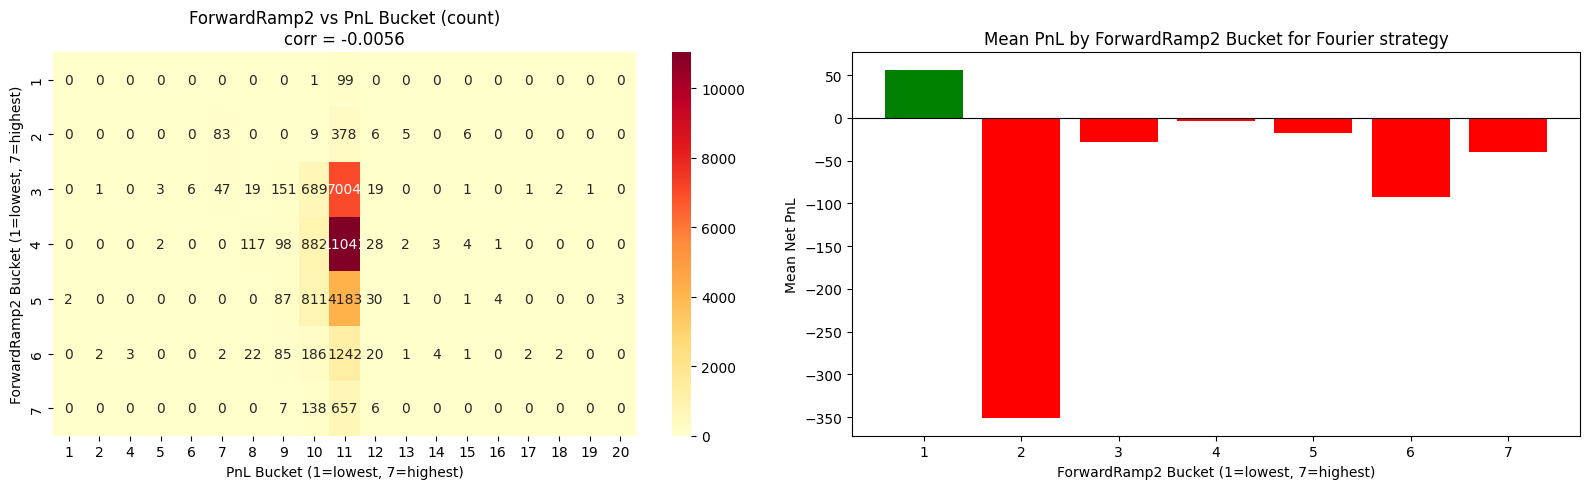


Correlation BackwardRamp2 vs pnl_bucket: 0.0136


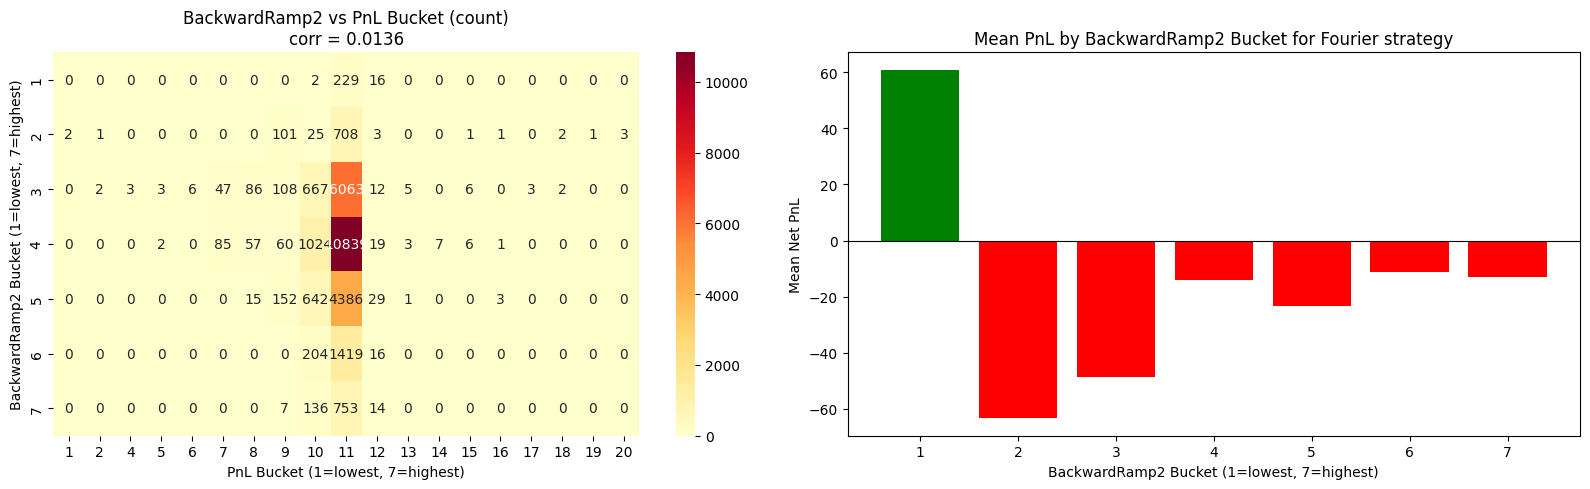


Correlation wind_bucket vs pnl_bucket: 0.0677


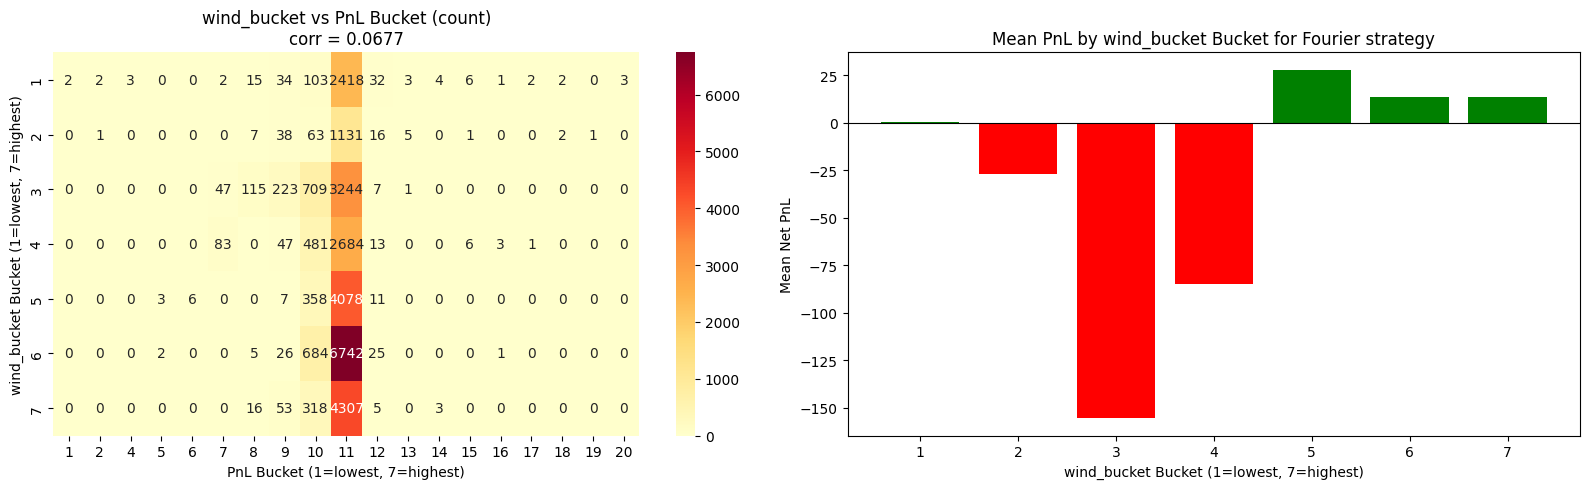

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
for ramp_col, title in [('ForwardRamp2_bucket_num', 'ForwardRamp2'), 
                         ('BackwardRamp2_bucket_num', 'BackwardRamp2'),
                         ('wind_bucket_num','wind_bucket')]:

    comb_ramp = combined[
        (combined[ramp_col] > 0) &
        (combined['pnl_bucket_num'] > 0)
    ]

    corr_ramp = comb_ramp[[ramp_col, 'pnl_bucket_num']].corr()['pnl_bucket_num'][ramp_col]
    print(f"\nCorrelation {title} vs pnl_bucket: {corr_ramp:.4f}")

    counts_ramp = comb_ramp.groupby([ramp_col, 'pnl_bucket_num']).size().reset_index(name='count')
    pivot_ramp  = counts_ramp.pivot_table(index=ramp_col, columns='pnl_bucket_num', values='count', fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.heatmap(pivot_ramp, ax=axes[0], annot=True, fmt='.0f', cmap='YlOrRd')
    axes[0].set_title(f'{title} vs PnL Bucket (count)\ncorr = {corr_ramp:.4f}')
    axes[0].set_xlabel('PnL Bucket (1=lowest, 7=highest)')
    axes[0].set_ylabel(f'{title} Bucket (1=lowest, 7=highest)')

    mean_pnl_ramp = comb_ramp.groupby(ramp_col)['net_pnl'].mean()
    axes[1].bar(mean_pnl_ramp.index, mean_pnl_ramp.values,
                color=['red' if v < 0 else 'green' for v in mean_pnl_ramp.values])
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title(f'Mean PnL by {title} Bucket for {strategy} strategy')
    axes[1].set_xlabel(f'{title} Bucket (1=lowest, 7=highest)')
    axes[1].set_ylabel('Mean Net PnL')
    axes[1].set_xticks(mean_pnl_ramp.index)

    plt.tight_layout()
    plt.show()


# Load bucket and the profit

In [150]:
all_results = []

def simulate_dfs(bid_date):
    global df_wind, df_load
    for i in bid_date:
        dt_str  = pd.Timestamp(i).strftime('%Y-%m-%d')
        sim_end = (pd.Timestamp(i)).strftime('%Y-%m-%d')

        df1 = simulate_total_ftp(dt_str, sim_end, 0, 'Darwin').merge(df_loadwind, on=['dt','hr']) \
                .groupby(['sim_dt_str', 'load_bucket']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl'}).reset_index()
        
        df2 = simulate_total_ftp(dt_str, sim_end, 0, 'Fourier').merge(df_loadwind, on=['dt','hr']) \
                .groupby(['sim_dt_str', 'load_bucket']).sum(numeric_only=True)[['net_pnl']].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl'}).reset_index()
        
        df3 = simulate_total_mte(dt_str, sim_end, 0, 'Darwin').merge(df_loadwind, on=['dt','hr','BAA'])  \
                .groupby(['sim_dt_str', 'load_bucket']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Darwin_net_pnl', "slack_pnl":'Darwin_slack_pnl',"cong_pnl":'Darwin_cong_pnl'}).reset_index()

        df4 = simulate_total_mte(dt_str, sim_end, 0, 'Fourier').merge(df_loadwind, on=['dt','hr','BAA']) \
                .groupby(['sim_dt_str', 'load_bucket']).sum(numeric_only=True)[['net_pnl',"slack_pnl","cong_pnl"]].round(0) \
                .rename(columns={'net_pnl': 'Fourier_net_pnl', "slack_pnl":'Fourier_slack_pnl',"cong_pnl":'Fourier_cong_pnl'}).reset_index()
        
        
        merged = df1.merge(df2, on=['sim_dt_str', 'load_bucket'], how='outer') \
                    .merge(df3, on=['sim_dt_str', 'load_bucket'], how='outer') \
                    .merge(df4, on=['sim_dt_str', 'load_bucket'], how='outer') \
                    .rename(columns={'sim_dt_str': 'dt'})


        print(f"\n{'─'*50}")
        print(f"Bid date: {dt_str}")
        print(merged.to_string(index=False))
        all_results.append(merged)

    return pd.concat(all_results, ignore_index=True)


# ── Run ───────────────────────────────────────────────────────────────────────
start_dt = '2026-03-15'
end_dt   = '2026-03-28'
all_results = []

df_wind = sql_functions.download_df_from_sql_db(
    "select dt,hr, Gen_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_wind_forecast_mte "
    "where baa_zone = 'E'")

df_wind['wind_bucket'] = pd.cut(df_wind['Gen_MW'], bins=7)
df_wind['dt'] = df_wind['dt'].astype(str)

df_load = sql_functions.download_df_from_sql_db(
    "select dt,hr, load_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_load_forecast_mte "
    "where baa_zone = 'E'")

df_load['dt'] = df_load['dt'].astype(str)
df_load = df_load[df_load['dt'].isin(df_wind['dt'].unique())]
df_load['load_bucket'] = pd.cut(df_load['load_MW'], bins=7)



df_loadwind = df_load.merge(df_wind, on =['dt','hr','BAA'])
df_loadwind['loadwind'] = df_loadwind['load_MW']-df_loadwind['Gen_MW']

for i in pd.date_range(start_dt, end_dt):
    simulate_dfs([i])

finals = pd.concat(all_results, ignore_index=True)

# ── Excel ─────────────────────────────────────────────────────────────────────
output_path = '/var/www/python/Qingcheng/WFiles/simulation_results_load.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    finals.to_excel(writer, sheet_name='Darwin_vs_Fourier', index=False)

print(f"\nSaved → {output_path}")


──────────────────────────────────────────────────
Bid date: 2026-03-15
        dt            load_bucket  Darwin_net_pnl_x  Fourier_net_pnl_x  Darwin_net_pnl_y  Darwin_slack_pnl  Darwin_cong_pnl  Fourier_net_pnl_y  Fourier_slack_pnl  Fourier_cong_pnl
2026-03-15 (26313.549, 28392.429]           21146.0             6002.0          -15109.0          -37849.0          25648.0           -29845.0           -12861.0          -15259.0
2026-03-15 (28392.429, 30456.857]            6029.0             3399.0           -5009.0          -18405.0          14321.0            -5079.0           -26925.0           22511.0
2026-03-15 (30456.857, 32521.286]           -3160.0             5496.0           -6420.0            4424.0         -10558.0           -25957.0           -57005.0           28889.0
2026-03-15 (32521.286, 34585.714]            5023.0            -4686.0           -4020.0           -7860.0           4093.0           -83014.0          -104755.0           20231.0
2026-03-15 (34585.714, 3665

KeyError: 'da_slack'

# ALL variables creating the meta table

In [1]:
def simulate_total_ftp(bid_date, sim_end_date,lookback_days, strategy):

    MARKET_CONFIG = {
    'SPP': {
        'load_table': 'spp_physical.spp_latest_load_forecast',
        'wind_table': 'spp_physical.spp_latest_wind_forecast',
        'inc_op_rate': 2.0,
        'dec_op_rate': 0.1
    },
    'PJM': {
        'load_table': '',
        'wind_table': '',
        'inc_op_rate': 0.0,
        'dec_op_rate': 0.0
    },
    'MISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'ERCOT': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'NYISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
}
    
    m_cfg = MARKET_CONFIG['SPP']

    strat_list = [strategy] if (strategy and strategy != 'All') else None
    bid_manager = DailyBidsManager(opexchange='SPP', bid_date=str(bid_date), portfolio=pd.DataFrame())
    df_bids = bid_manager.get_bids_from_table(label='current', strategy_ls=strat_list)
    df_bids.rename(columns={'dt': 'source_dt'}, inplace=True)
    expected_cols = ['source_dt', 'hr', 'node_num', 'node_name', 'bid_mw', 'bid_price', 'incdec', 'strategy']
    df_bids = df_bids[[c for c in expected_cols if c in df_bids.columns]]

    if df_bids.empty:
        return [], [], [], [], get_fig(), {"display": "none"}

    df_bids['hr'] = df_bids['hr'].astype(int)
    df_bids['node_num'] = df_bids['node_num'].astype(int)

    # 2. Date Range & Cross Join
    sim_end_obj = pd.to_datetime(sim_end_date).date()
    target_end_date = sim_end_obj 
    target_start_date = sim_end_obj - timedelta(days=int(lookback_days))

    date_range = pd.date_range(start=target_start_date, end=target_end_date, freq='D')
    df_dates = pd.DataFrame({'sim_dt': date_range})
    df_dates['sim_dt_str'] = df_dates['sim_dt'].dt.strftime('%Y-%m-%d')

    df_dates['key'] = 1
    df_bids['key'] = 1
    df_sim = pd.merge(df_dates, df_bids, on='key').drop('key', axis=1)

    # 3. Prices
    node_list = df_bids['node_num'].unique().tolist()

    node_obj = Node(node_nums=node_list, market='SPP')
    df_prices = node_obj.get_price(
        start_dt=str(target_start_date),
        end_dt=str(target_end_date),
        component=['LMP'],
        type=['DA', 'RT'],
        granularity='hourly'
    )

    if not df_prices.empty:
        df_prices.rename(columns={'da_total': 'dalmp', 'rt_total': 'rtlmp'}, inplace=True)
        df_prices['hr'] = df_prices['hr'].astype(int)
        df_prices['node_num'] = df_prices['node_num'].astype(int)
        df_sim = pd.merge(df_sim, df_prices, left_on=['sim_dt_str', 'hr', 'node_num'],
                            right_on=['dt', 'hr', 'node_num'], how='left')
    else:
        df_sim['dalmp'] = np.nan
        df_sim['rtlmp'] = np.nan

    # 4. Calculations (Preserved as per instruction)
    inc_op_rate = m_cfg['inc_op_rate']
    dec_op_rate = m_cfg['dec_op_rate']

    conditions_clear = [
        (df_sim['incdec'] == 'Decrement') & (df_sim['bid_price'] >= df_sim['dalmp']),
        (df_sim['incdec'] == 'Increment') & (df_sim['bid_price'] <= df_sim['dalmp'])
    ]
    df_sim['is_cleared'] = np.select(conditions_clear, [True, True], default=False)
    df_sim.loc[df_sim['dalmp'].isna(), 'is_cleared'] = False
    df_sim['clear_mw'] = np.where(df_sim['is_cleared'], df_sim['bid_mw'], 0.0)

    # DA & RT Cash
    df_sim['total_da_val'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['dalmp'], df_sim['clear_mw'] * df_sim['dalmp'])
    df_sim['total_da_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_val'])

    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rtlmp'], -1 * df_sim['clear_mw'] * df_sim['rtlmp'])
    df_sim['total_rt_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)

    # RSG
    rsg_cost = np.where(df_sim['incdec'] == 'Increment', df_sim['clear_mw'] * inc_op_rate, df_sim['clear_mw'] * dec_op_rate)
    df_sim['op_rate_val'] = np.where(df_sim['rtlmp'].isna(), 0, -1 * rsg_cost)

    # Totals
    df_sim['gross_pnl'] = df_sim['total_da_elapsed'] + df_sim['total_rt_elapsed']
    df_sim['net_pnl'] = df_sim['gross_pnl'] + df_sim['op_rate_val']
    df_sim.fillna(0, inplace=True)

    # 5. Aggregation & Data Return

    agg_dict = {
        'bid_mw': 'sum', 'clear_mw': 'sum',
        'total_da_val': 'sum', 'total_da_elapsed': 'sum', 'total_rt_elapsed': 'sum', 'op_rate_val': 'sum',
        'gross_pnl': 'sum', 'net_pnl': 'sum'
    }
    renamer = {
        'bid_mw': 'BidMW', 'clear_mw': 'ClearMW',
        'total_da_val': 'TotalDA$', 'total_da_elapsed': 'TotalDAElapsed$',
        'total_rt_elapsed': 'TotalRTElapsed$', 'op_rate_val': 'OpRate$',
        'gross_pnl': 'Gross$', 'net_pnl': 'Net$'
    }

    # A. Overall Summary
    summ_data = df_sim.agg(agg_dict).to_frame().T.rename(columns=renamer).to_dict('records')

    # B. Portfolio Summary
    port_data = df_sim.groupby('strategy').agg(agg_dict).reset_index().rename(columns=renamer).to_dict('records')

    # C. Daily Summary
    daily_df = df_sim.groupby('sim_dt_str').agg(agg_dict).reset_index().rename(columns=renamer)
    daily_df.rename(columns={'sim_dt_str': 'dt'}, inplace=True)
    return df_sim

In [2]:

def simulate_total_mte(bid_date, sim_end_date,lookback_days, strategy):

    MARKET_CONFIG = {
    'SPP': {
        'load_table': 'spp_physical.spp_latest_load_forecast',
        'wind_table': 'spp_physical.spp_latest_wind_forecast',
        'inc_op_rate': 2.0,
        'dec_op_rate': 0.1
    },
    'PJM': {
        'load_table': '',
        'wind_table': '',
        'inc_op_rate': 0.0,
        'dec_op_rate': 0.0
    },
    'MISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'ERCOT': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'NYISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
}
    
    m_cfg = MARKET_CONFIG['SPP']

    strat_list = [strategy] if (strategy and strategy != 'All') else None
    bid_manager = DailyBidsManager(opexchange='SPP', bid_date=str(bid_date), portfolio=pd.DataFrame())
    df_bids = bid_manager.get_bids_from_table(label='current', strategy_ls=strat_list)
    df_bids.rename(columns={'dt': 'source_dt'}, inplace=True)
    expected_cols = ['source_dt', 'hr', 'node_num', 'node_name', 'bid_mw', 'bid_price', 'incdec', 'strategy']
    df_bids = df_bids[[c for c in expected_cols if c in df_bids.columns]]

    if df_bids.empty:
        return [], [], [], [], get_fig(), {"display": "none"}

    df_bids['hr'] = df_bids['hr'].astype(int)
    df_bids['node_num'] = df_bids['node_num'].astype(int)


    # 2. Date Range & Cross Join
    sim_end_obj = pd.to_datetime(sim_end_date).date()
    target_end_date = sim_end_obj
    target_start_date = sim_end_obj - timedelta(days=int(lookback_days))
    # print('simulation start date is ', target_start_date)
    # print('simulation end date is ', target_end_date)

    date_range = pd.date_range(start=target_start_date, end=target_end_date, freq='D')
    df_dates = pd.DataFrame({'sim_dt': date_range})
    df_dates['sim_dt_str'] = df_dates['sim_dt'].dt.strftime('%Y-%m-%d')

    df_dates['key'] = 1
    df_bids['key'] = 1
    df_sim = pd.merge(df_dates, df_bids, on='key').drop('key', axis=1)

    # 3. Prices

    da_prices = sql_functions.download_df_from_sql_db(f'''select * from spp_temp.settlement_location_da_hourly_mte where dt>='{target_start_date}' and dt <='{target_end_date}' ''')
    rt_prices = sql_functions.download_df_from_sql_db(f'''select * from spp_temp.settlement_location_rt_hourly_mte where dt>='{target_start_date}' and dt <='{target_end_date}' ''')
    da_prices['da_slack']=da_prices['da_value']-da_prices['congestional_value']-da_prices['marginalloss_value']
    rt_prices['rt_slack']=rt_prices['rt_value']-rt_prices['congestional_value']-rt_prices['marginalloss_value']
    df_prices= pd.merge(da_prices, rt_prices, on=['dt', 'hr', 'node_num'], how='left')



    # select_cols= ['dt','hr','settlement_location','da_value','rt_value','congestional_value','marginalloss_value','node_num']
    # df_prices= df_prices[select_cols]
    if not df_prices.empty:
        df_prices.rename(columns={'da_value': 'dalmp', 'rt_value': 'rtlmp'}, inplace=True)
        df_prices['hr'] = df_prices['hr'].astype(int)
        df_prices['node_num'] = df_prices['node_num'].astype(int)
        df_prices['dt'] = df_prices['dt'].astype(str)
        df_sim = pd.merge(df_sim, df_prices, left_on=['sim_dt_str', 'hr', 'node_num'],
                            right_on=['dt', 'hr', 'node_num'], how='left')
    else:
        df_sim['dalmp'] = np.nan
        df_sim['rtlmp'] = np.nan

    # 4. Calculations (Preserved as per instruction)
    inc_op_rate = m_cfg['inc_op_rate']
    dec_op_rate = m_cfg['dec_op_rate']

    conditions_clear = [
        (df_sim['incdec'] == 'Decrement') & (df_sim['bid_price'] >= df_sim['dalmp']),
        (df_sim['incdec'] == 'Increment') & (df_sim['bid_price'] <= df_sim['dalmp'])
    ]
    df_sim['is_cleared'] = np.select(conditions_clear, [True, True], default=False)
    df_sim.loc[df_sim['dalmp'].isna(), 'is_cleared'] = False
    df_sim['clear_mw'] = np.where(df_sim['is_cleared'], df_sim['bid_mw'], 0.0)

    # DA & RT Cash
    df_sim['total_da_val'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['dalmp'], df_sim['clear_mw'] * df_sim['dalmp'])
    df_sim['total_da_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_val'])
    df_sim['total_da_slack'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['da_slack'], df_sim['clear_mw'] * df_sim['da_slack'])
    df_sim['total_da_slack_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_slack'])
    df_sim['total_da_congestional'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['congestional_value_x'], df_sim['clear_mw'] * df_sim['congestional_value_x'])
    df_sim['total_da_cong_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_congestional'])

    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rtlmp'], -1 * df_sim['clear_mw'] * df_sim['rtlmp'])
    df_sim['total_rt_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rt_slack'], -1 * df_sim['clear_mw'] * df_sim['rt_slack'])
    df_sim['total_rt_slack_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['congestional_value_y'], -1 * df_sim['clear_mw'] * df_sim['congestional_value_y'])
    df_sim['total_rt_cong_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    

    # RSG
    rsg_cost = np.where(df_sim['incdec'] == 'Increment', df_sim['clear_mw'] * inc_op_rate, df_sim['clear_mw'] * dec_op_rate)
    df_sim['op_rate_val'] = np.where(df_sim['rtlmp'].isna(), 0, -1 * rsg_cost)

    # Totals
    df_sim['gross_pnl'] = df_sim['total_da_elapsed'] + df_sim['total_rt_elapsed']
    df_sim['net_pnl'] = df_sim['gross_pnl'] + df_sim['op_rate_val']
    df_sim['slack_pnl'] = df_sim['total_da_slack_elapsed']+df_sim['total_rt_slack_elapsed']
    df_sim['cong_pnl'] = df_sim['total_da_cong_elapsed']+df_sim['total_rt_cong_elapsed']
    
    df_sim.fillna(0, inplace=True)
    df_sim.sort_values(by=['gross_pnl'],ascending=True,inplace=True)


    # 5. Aggregation & Data Return

    agg_dict = {
        'bid_mw': 'sum', 'clear_mw': 'sum',
        'total_da_val': 'sum', 'total_da_elapsed': 'sum', 'total_rt_elapsed': 'sum', 'op_rate_val': 'sum',
        'gross_pnl': 'sum', 'net_pnl': 'sum'
    }
    renamer = {
        'bid_mw': 'BidMW', 'clear_mw': 'ClearMW',
        'total_da_val': 'TotalDA$', 'total_da_elapsed': 'TotalDAElapsed$',
        'total_rt_elapsed': 'TotalRTElapsed$', 'op_rate_val': 'OpRate$',
        'gross_pnl': 'Gross$', 'net_pnl': 'Net$'
    }

    # A. Overall Summary
    summ_data = df_sim.agg(agg_dict).to_frame().T.rename(columns=renamer).to_dict('records')

    # B. Portfolio Summary
    port_data = df_sim.groupby('strategy').agg(agg_dict).reset_index().rename(columns=renamer).to_dict('records')

    # C. Daily Summary
    daily_df = df_sim.groupby('sim_dt_str').agg(agg_dict).reset_index().rename(columns=renamer)
    daily_df.rename(columns={'sim_dt_str': 'dt'}, inplace=True)

    return df_sim

In [5]:
# wind data
df_wind = sql_functions.download_df_from_sql_db(
    "select dt,hr, Gen_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_wind_forecast_mte")

df_wind = df_wind.pivot_table(index=['dt', 'hr'], columns='BAA', values='Gen_MW').reset_index()
df_wind.columns.name = None
df_wind = df_wind.rename(columns={'E': 'wind_E', 'W': 'wind_W'})
df_wind['wind_total'] = df_wind['wind_E']+df_wind['wind_W']
df_wind['dt'] = df_wind['dt'].astype(str)
df_wind.sort_values(by = ['dt','hr'],inplace=True)
df_wind['Framp_wind_1']  = df_wind['wind_E'].diff(-1) / -1
df_wind['Framp_wind_2']  = df_wind['wind_E'].diff(-2) / -2
df_wind['Framp_wind_3']  = df_wind['wind_E'].diff(-3) / -3
df_wind['Framp_wind_4']  = df_wind['wind_E'].diff(-4) / -4
df_wind['Bramp_wind_1']  = df_wind['wind_E'].diff(1) / 1
df_wind['Bramp_wind_2']  = df_wind['wind_E'].diff(2) / 2
df_wind['Bramp_wind_3']  = df_wind['wind_E'].diff(3) / 3
df_wind['Bramp_wind_4']  = df_wind['wind_E'].diff(4) / 4
df_wind['Framp_wind_total_1']  = df_wind['wind_total'].diff(-1) / -1
df_wind['Framp_wind_total_2']  = df_wind['wind_total'].diff(-2) / -2
df_wind['Framp_wind_total_3']  = df_wind['wind_total'].diff(-3) / -3
df_wind['Framp_wind_total_4']  = df_wind['wind_total'].diff(-4) / -4
df_wind['Bramp_wind_total_1']  = df_wind['wind_total'].diff(1) / 1
df_wind['Bramp_wind_total_2']  = df_wind['wind_total'].diff(2) / 2
df_wind['Bramp_wind_total_3']  = df_wind['wind_total'].diff(3) / 3
df_wind['Bramp_wind_total_4']  = df_wind['wind_total'].diff(4) / 4
df_wind = df_wind.ffill().bfill()

# solar data
df_solar = sql_functions.download_df_from_sql_db(
    "select dt,hr, Gen_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_solar_forecast_mte ")
df_solar.fillna(0, inplace=True)
df_solar = df_solar.pivot_table(index=['dt', 'hr'], columns='BAA', values='Gen_MW').reset_index()
df_solar = df_solar.rename(columns={'E': 'solar_E', 'W': 'solar_W'})
df_solar['solar_total'] = df_solar['solar_E']+df_solar['solar_W']
df_solar['dt'] = df_solar['dt'].astype(str)

# load data
df_load = sql_functions.download_df_from_sql_db(
    "select dt,hr, load_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_load_forecast_mte")
df_load['dt'] = df_load['dt'].astype(str)
df_load = df_load[df_load['dt'].isin(df_wind['dt'].unique())]
df_load = df_load.pivot_table(index=['dt', 'hr'], columns='BAA', values='load_MW').reset_index()
df_load.columns.name = None
df_load = df_load.rename(columns={'E': 'load_E', 'W': 'load_W'})
df_load['load_total'] = df_load['load_E']+df_load['load_W']

# merge them 
df_phy=df_wind.merge(df_load, on=['dt','hr']).merge(df_solar,on=['dt','hr'])

# Null check
print("Null counts:")
print(df_phy.isnull().sum())

# Date range check
print(f"\nDate range: {df_phy['dt'].min()} to {df_phy['dt'].max()}")

# Check all dt/hr combinations are present
expected = pd.MultiIndex.from_product(
    [pd.date_range('2026-03-15', '2026-03-28').astype(str), range(1, 25)],
    names=['dt', 'hr']
)
actual = pd.MultiIndex.from_frame(df_phy[['dt', 'hr']])
missing = expected.difference(actual)

if missing.empty:
    print("\nAll dt/hr present ✓")
else:
    print(f"\nMissing {len(missing)} dt/hr combinations:")
    print(missing.to_frame(index=False))
    
# load-wind-solar variables 
df_phy['load_wind'] = df_phy['load_total'] - df_phy['wind_total']
df_phy['load_wind_E'] = df_phy['load_E'] - df_phy['wind_E']
df_phy['load_wind_solar'] = df_phy['load_total'] - df_phy['wind_total'] - df_phy['solar_total']
df_phy['load_wind_solar_E'] = df_phy['load_E'] - df_phy['wind_E'] - df_phy['solar_E']

df_phy['Framp_lws_E_1']  = df_phy['load_wind_solar_E'].diff(-1) / -1
df_phy['Framp_lws_E_2']  = df_phy['load_wind_solar_E'].diff(-2) / -2
df_phy['Framp_lws_E_3']  = df_phy['load_wind_solar_E'].diff(-3) / -3
df_phy['Framp_lws_E_4']  = df_phy['load_wind_solar_E'].diff(-4) / -4
df_phy['Bramp_lws_E_1']  = df_phy['load_wind_solar_E'].diff(1) / 1
df_phy['Bramp_lws_E_2']  = df_phy['load_wind_solar_E'].diff(2) / 2
df_phy['Bramp_lws_E_3']  = df_phy['load_wind_solar_E'].diff(3) / 3
df_phy['Bramp_lws_E_4']  = df_phy['load_wind_solar_E'].diff(4) / 4
df_phy['Framp_lws_total_1']  = df_phy['load_wind_solar'].diff(-1) / -1
df_phy['Framp_lws_total_2']  = df_phy['load_wind_solar'].diff(-2) / -2
df_phy['Framp_lws_total_3']  = df_phy['load_wind_solar'].diff(-3) / -3
df_phy['Framp_lws_total_4']  = df_phy['load_wind_solar'].diff(-4) / -4
df_phy['Bramp_lws_total_1']  = df_phy['load_wind_solar'].diff(1) / 1
df_phy['Bramp_lws_total_2']  = df_phy['load_wind_solar'].diff(2) / 2
df_phy['Bramp_lws_total_3']  = df_phy['load_wind_solar'].diff(3) / 3
df_phy['Bramp_lws_total_4']  = df_phy['load_wind_solar'].diff(4) / 4
df_phy = df_phy.ffill().bfill()
print("Null counts:")
print(df_phy.isnull().sum())

Null counts:
dt                    0
hr                    0
wind_E                0
wind_W                0
wind_total            0
Framp_wind_1          0
Framp_wind_2          0
Framp_wind_3          0
Framp_wind_4          0
Bramp_wind_1          0
Bramp_wind_2          0
Bramp_wind_3          0
Bramp_wind_4          0
Framp_wind_total_1    0
Framp_wind_total_2    0
Framp_wind_total_3    0
Framp_wind_total_4    0
Bramp_wind_total_1    0
Bramp_wind_total_2    0
Bramp_wind_total_3    0
Bramp_wind_total_4    0
load_E                0
load_W                0
load_total            0
solar_E               0
solar_W               0
solar_total           0
dtype: int64

Date range: 2026-03-15 to 2026-03-29

All dt/hr present ✓
Null counts:
dt                    0
hr                    0
wind_E                0
wind_W                0
wind_total            0
Framp_wind_1          0
Framp_wind_2          0
Framp_wind_3          0
Framp_wind_4          0
Bramp_wind_1          0
Bramp_wind_2  

In [6]:
# Download the rt/da data 
df_rt = sql_functions.download_df_from_sql_db(
    "select * "
    "from spp_temp.settlement_location_rt_hourly_mte")

df_da = sql_functions.download_df_from_sql_db(
    "select * "
    "from spp_temp.settlement_location_da_hourly_mte")

df_rt['dt'] = df_rt['dt'].astype(str)
df_da['dt'] = df_da['dt'].astype(str)
df_rt['rt_slack'] = df_rt['rt_value'] - df_rt['congestional_value'] - df_rt['marginalloss_value']
df_da['da_slack'] = df_da['da_value'] - df_da['congestional_value'] - df_da['marginalloss_value']

In [7]:
# price final table
df_rt_temp=df_rt.drop(columns=['BAA','marginalloss_value']).rename(columns={'congestional_value':'cong_rt'})
df_da=df_da.rename(columns={'congestional_value':'cong_da'})
df_price = df_rt_temp.merge(df_da, on=['dt','hr','node_num']).merge(df_phy, on=['dt','hr'])

# # ── Excel ─────────────────────────────────────────────────────────────────────
# output_path = '/var/www/python/Qingcheng/WFiles/rto_mte_price.csv'
# df_price.to_csv(output_path, index=False)
# print(f"\nSaved → {output_path}")

In [9]:
# profit final table
def simulate_dfs(bid_date):
    global all_results
    for i in bid_date:
        dt_str  = pd.Timestamp(i).strftime('%Y-%m-%d')
        sim_end = (pd.Timestamp(i)).strftime('%Y-%m-%d')
        df1 = simulate_total_mte(dt_str, sim_end, 0, 'Darwin')
        df2 = simulate_total_mte(dt_str, sim_end, 0, 'Fourier')
        
        merged = pd.concat([df1, df2], ignore_index=True)


        print(f"\n{'─'*50}")
        print(f"Bid date: {dt_str}")
        all_results.append(merged)

    return pd.concat(all_results, ignore_index=True)


# ── Run ───────────────────────────────────────────────────────────────────────
start_dt = '2026-03-17'
end_dt   = '2026-03-28'
all_results = []
for i in pd.date_range(start_dt, end_dt):
    simulate_dfs([i])
df_profit_mte = pd.concat(all_results, ignore_index=True)


──────────────────────────────────────────────────
Bid date: 2026-03-17

──────────────────────────────────────────────────
Bid date: 2026-03-18

──────────────────────────────────────────────────
Bid date: 2026-03-19

──────────────────────────────────────────────────
Bid date: 2026-03-20

──────────────────────────────────────────────────
Bid date: 2026-03-21

──────────────────────────────────────────────────
Bid date: 2026-03-22

──────────────────────────────────────────────────
Bid date: 2026-03-23

──────────────────────────────────────────────────
Bid date: 2026-03-24

──────────────────────────────────────────────────
Bid date: 2026-03-25

──────────────────────────────────────────────────
Bid date: 2026-03-26

──────────────────────────────────────────────────
Bid date: 2026-03-27

──────────────────────────────────────────────────
Bid date: 2026-03-28


In [133]:
# ── Run ───────────────────────────────────────────────────────────────────────
start_dt = '2026-03-17'
end_dt   = '2026-03-28'
all_results = []
def simulate_dfs_ftp(bid_date):
    global all_results
    for i in bid_date:
        dt_str  = pd.Timestamp(i).strftime('%Y-%m-%d')
        sim_end = (pd.Timestamp(i)).strftime('%Y-%m-%d')
        df1 = simulate_total_ftp(dt_str, sim_end, 0, 'Darwin')
        df2 = simulate_total_ftp(dt_str, sim_end, 0, 'Fourier')
        merged = pd.concat([df1, df2], ignore_index=True)

        print(f"\n{'─'*50}")
        print(f"Bid date: {dt_str}")
        all_results.append(merged)

    return pd.concat(all_results, ignore_index=True)

for i in pd.date_range(start_dt, end_dt):
    simulate_dfs_ftp([i])
df_profit_ftp = pd.concat(all_results, ignore_index=True)


──────────────────────────────────────────────────
Bid date: 2026-03-17

──────────────────────────────────────────────────
Bid date: 2026-03-18

──────────────────────────────────────────────────
Bid date: 2026-03-19

──────────────────────────────────────────────────
Bid date: 2026-03-20

──────────────────────────────────────────────────
Bid date: 2026-03-21

──────────────────────────────────────────────────
Bid date: 2026-03-22

──────────────────────────────────────────────────
Bid date: 2026-03-23

──────────────────────────────────────────────────
Bid date: 2026-03-24

──────────────────────────────────────────────────
Bid date: 2026-03-25

──────────────────────────────────────────────────
Bid date: 2026-03-26

──────────────────────────────────────────────────
Bid date: 2026-03-27

──────────────────────────────────────────────────
Bid date: 2026-03-28


In [10]:
# profit table final 
columns = ['dt','hr','BAA','incdec','strategy','dalmp','rtlmp','clear_mw','node_num','net_pnl','slack_pnl','cong_pnl']
df_profit_mte = df_profit_mte[columns]
df_profit = df_profit_mte.merge(df_phy, on=['dt','hr'])

# output_path = '/var/www/python/Qingcheng/WFiles/rto_mte_profit.csv'
# df_profit.to_csv(output_path, index=False)
# print(f"\nSaved → {output_path}")

In [ ]:
# profit table final 
columns = ['dt','hr','incdec','strategy','dalmp','rtlmp','clear_mw','node_num','net_pnl']
df_profit_ftp = df_profit_ftp[columns]
df_profit_ftp = df_profit_ftp.merge(df_phy, on=['dt','hr'])

In [17]:
# generate model to determine importance of the variables 
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import cross_val_score


def rf_importance(df, x_vars, y_var, n_estimators=100, max_depth=10, random_state=42):
    clean = df[x_vars + [y_var]].dropna()
    X, y = clean[x_vars], clean[y_var]

    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=random_state)
    model.fit(X, y)

    importance = pd.Series(model.feature_importances_, index=x_vars).sort_values(ascending=False)
    return importance


def lr_importance(df, x_vars, y_var):
    clean = df[list(x_vars) + [y_var]].dropna()
    X, y = clean[x_vars], clean[y_var]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LinearRegression()
    model.fit(X_scaled, y)

    importance = pd.Series(model.coef_, index=x_vars)
    return importance.reindex(importance.abs().sort_values(ascending=False).index)

from sklearn.ensemble import RandomForestClassifier
def rf_importance_clf(df, x_vars, y_var, n_estimators=100, max_depth=10, random_state=42):
    clean = df[list(x_vars) + [y_var]].dropna()
    X, y = clean[list(x_vars)], clean[y_var]

    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=random_state)
    model.fit(X, y)

    y_pred = model.predict(X)
    cv_acc = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()

    print(f"── Model Performance ──────────────────")
    print(f"  Train Accuracy : {model.score(X, y):.4f}")
    print(f"  CV Accuracy    : {cv_acc:.4f}  (5-fold)")
    print(f"  Classes        : {model.classes_.tolist()}")
    print(f"───────────────────────────────────────")

    importance = pd.Series(model.feature_importances_, index=x_vars).sort_values(ascending=False)
    return importance



In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

def rf_pdp(df, x_vars, y_var, top_n=5, n_estimators=100, max_depth=5, random_state=42):
    clean = df[list(x_vars) + [y_var]].dropna()
    X, y = clean[list(x_vars)], clean[y_var]

    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=random_state)
    model.fit(X, y)

    # ── Model performance ─────────────────────────────────────────────────────
    y_pred = model.predict(X)
    train_mse = mean_squared_error(y, y_pred)
    train_r2  = r2_score(y, y_pred)
    train_rmse = root_mean_squared_error(y, y_pred)
    cv_rmse    = np.sqrt(-cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error').mean())


    cv_r2  = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    cv_mse = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error').mean()

    print(f"── Model Performance ──────────────────")
    print(f"  Train MSE : {train_mse:,.2f}")
    print(f"── Model Performance ──────────────────")
    print(f"  Train RMSE : {train_rmse:,.2f}")
    print(f"  Train R²   : {train_r2:.4f}")
    print(f"  CV R²      : {cv_r2:.4f}  (5-fold)")
    print(f"  CV RMSE    : {cv_rmse:,.2f}  (5-fold)")
    print(f"───────────────────────────────────────")
    print(f"───────────────────────────────────────")

    # ── Top variables ─────────────────────────────────────────────────────────
    importance = pd.Series(model.feature_importances_, index=x_vars).sort_values(ascending=False)
    top_vars = importance.head(top_n).index.tolist()
    top_idx  = [list(x_vars).index(v) for v in top_vars]

    print("\nTop variables:")
    print(importance.head(top_n))

    fig, axes = plt.subplots(1, top_n, figsize=(4 * top_n, 4))
    PartialDependenceDisplay.from_estimator(
        model, X, features=top_idx,
        feature_names=list(x_vars),
        ax=axes, line_kw={'color': 'steelblue'}
    )
    for ax, var in zip(axes, top_vars):
        ax.set_title(var, fontsize=9)
        ax.axhline(y.mean(), color='red', linestyle='--', linewidth=0.8)
        ax.set_xlabel(var)
        ax.set_ylabel(y_var)

    plt.suptitle(f'Partial Dependence of {y_var} on Top {top_n} Variables', y=1.02)
    plt.tight_layout()
    plt.show()


── Model Performance ──────────────────
  Train MSE : 2,178.36
── Model Performance ──────────────────
  Train RMSE : 46.67
  Train R²   : 0.8198
  CV R²      : -0.0743  (5-fold)
  CV RMSE    : 110.05  (5-fold)
───────────────────────────────────────
───────────────────────────────────────

Top variables:
wind_W                0.291389
load_wind             0.115071
load_wind_E           0.081547
Framp_wind_4          0.032320
Framp_wind_total_2    0.030964
dtype: float64


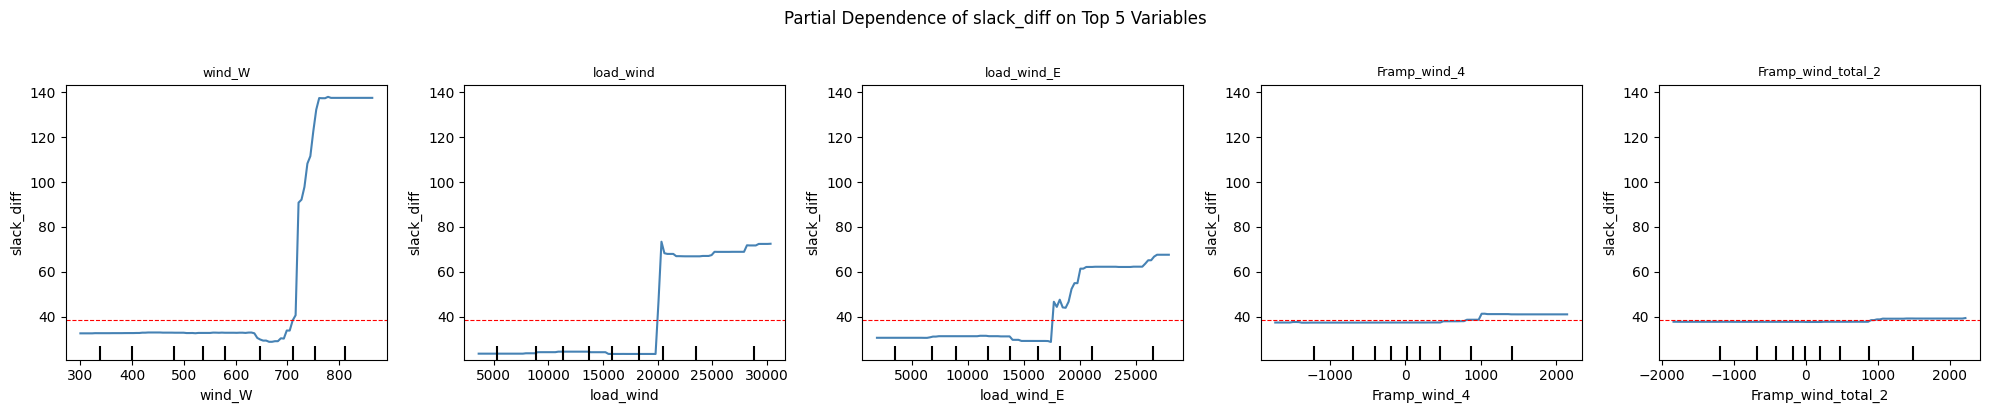

In [21]:
# price of node 636 
x_var = df_phy.columns.drop(['dt','hr']).tolist()
df_price['slack_diff']= df_price['rt_slack'] - df_price['da_slack']
df_price_636 = df_price[df_price['node_num']==636] 
df_price_636 = df_price_636[df_price_636['dt']>='2026-03-17']
rf_importance(df_price_636, x_var,'slack_diff')
rf_pdp(df_price_636, x_var,'slack_diff')
# lr_importance(df_price_636, x_var,'slack_diff')

── Model Performance ──────────────────
  Train MSE : 697.61
── Model Performance ──────────────────
  Train RMSE : 26.41
  Train R²   : 0.8003
  CV R²      : -0.0126  (5-fold)
  CV RMSE    : 57.53  (5-fold)
───────────────────────────────────────
───────────────────────────────────────

Top variables:
load_wind            0.176315
load_wind_E          0.097109
solar_E              0.062888
load_total           0.048311
Framp_lws_total_3    0.045502
dtype: float64


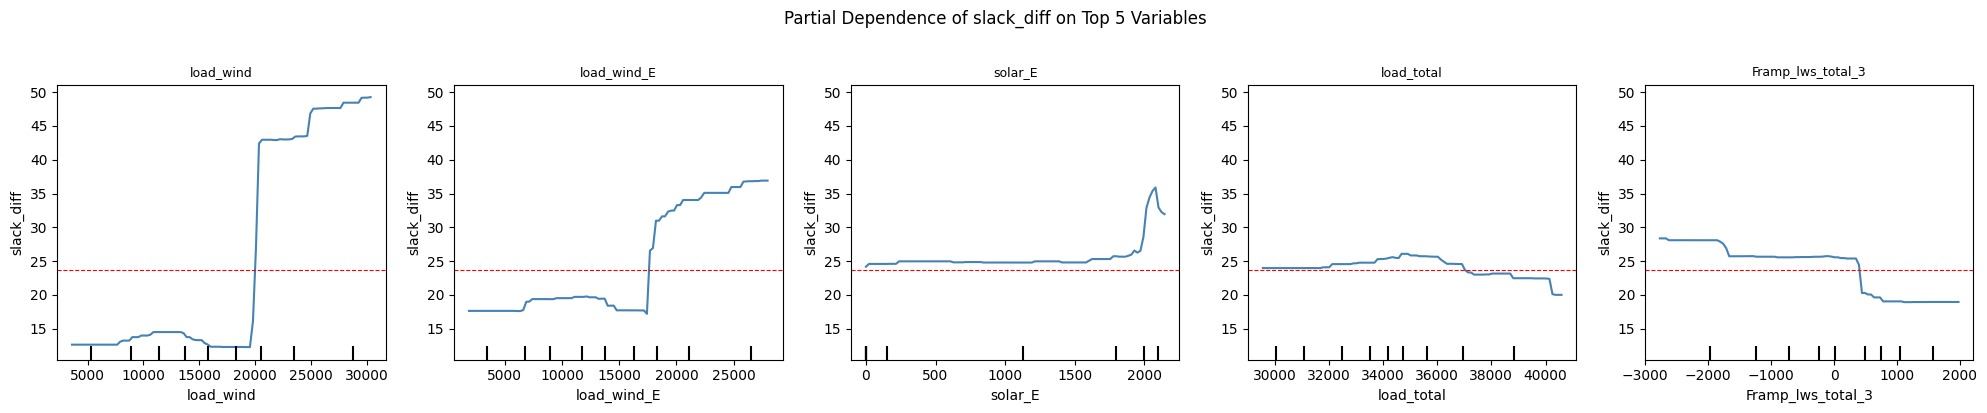

In [22]:
# price of node 636 
x_var = df_phy.columns.drop(['dt','hr']).tolist()
df_price['slack_diff']= df_price['rt_slack'] - df_price['da_slack']
df_price_636 = df_price[df_price['node_num']==636] 
df_price_636 = df_price_636[df_price_636['dt']>='2026-03-17']
df_price_636.loc[df_price_636['slack_diff']>150,'slack_diff']=150
df_price_636.loc[df_price_636['slack_diff']<=-150,'slack_diff']=-150
rf_importance(df_price_636, x_var,'slack_diff')
rf_pdp(df_price_636, x_var,'slack_diff')
# lr_importance(df_price_636, x_var,'slack_diff')

In [ ]:
# price of node 636 
x_var = df_phy.columns.drop(['dt','hr']).tolist()
df_price['slack_diff']= df_price['rt_slack'] - df_price['da_slack']
df_price_636 = df_price[df_price['node_num']==636] 
df_price_636 = df_price_636[df_price_636['dt']>='2026-03-17']                                          
df_price_636.loc[df_price_636['slack_diff']>150,'slack_diff']=150
df_price_636.loc[df_price_636['slack_diff']<=-150,'slack_diff']=-150
rf_importance(df_price_636, x_var,'slack_diff')
rf_pdp(df_price_636, x_var,'slack_diff')

<Axes: >

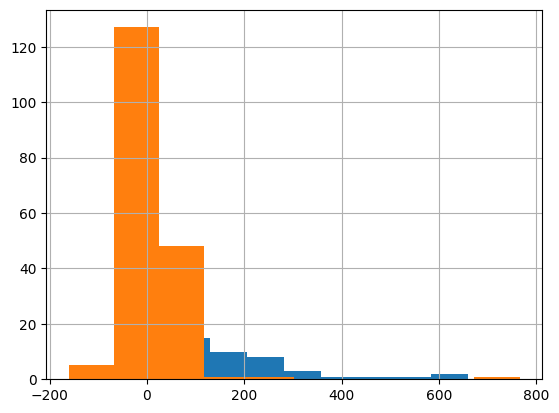

In [117]:
df_price_636 = df_price[df_price['node_num']==636] 
df_price_636 = df_price_636[df_price_636['dt']>='2026-03-17']
df_price_636[df_price_636['load_wind']>20000].slack_diff.hist()
df_price_636[df_price_636['load_wind']<20000].slack_diff.hist()


In [ ]:
df_profit[df_profit['load_wind']>20000].groupby(['strategy','incdec'])["net_pnl"].sum()

strategy  incdec   
Darwin    Decrement    1.139861e+06
          Increment   -7.243340e+05
Fourier   Decrement    1.877147e+05
          Increment   -9.816258e+05
Name: net_pnl, dtype: float64

In [ ]:
df_profit[df_profit['load_wind']>20000].groupby(['strategy','hr'])["net_pnl"]

strategy  hr
Darwin    1       2134.908706
          2        202.933800
          3        498.896550
          9      42073.042460
          10     15823.520940
          11      9403.914245
          12    -65868.309213
          13   -224823.271562
          14   -127657.616264
          15     42130.528458
          16     28269.919627
          17    119302.604073
          18     26816.512514
          19    108889.277121
          20    318003.170499
          21     52178.753155
          22     46003.778820
          23     23801.690610
          24     -1657.696266
Fourier   1       9618.775075
          2       8610.261400
          3       7073.700075
          9       1907.891904
          10      2258.049265
          11     13039.385212
          12    -75663.632648
          13   -220548.742756
          14   -149035.560150
          15    -91374.066804
          16    -65976.033030
          17     -3523.089701
          18    -33094.126116
          19    -64042.0482

In [130]:
df_price_636[df_price_636['load_wind']>20000].load_wind.count()
print(len(df_price_636))

269


In [ ]:
x_var = df_phy.columns.drop(['dt','hr']).tolist()
rf_importance(df_profit, x_var,'net_pnl')
rf_pdp(df_price_636, x_var,'slack_diff')

In [87]:
x_var = df_phy.columns.drop(['dt','hr']).tolist()
rf_importance(df_profit, x_var,'net_pnl')

wind_W                0.222781
Bramp_wind_3          0.136150
Framp_wind_1          0.066319
Framp_wind_total_1    0.054570
wind_E                0.054213
Bramp_wind_total_3    0.053128
solar_E               0.034042
load_wind             0.024520
Bramp_lws_E_3         0.020802
Bramp_lws_total_1     0.020780
Bramp_lws_total_3     0.020553
Bramp_lws_total_4     0.018766
Framp_lws_total_1     0.018310
Framp_lws_E_3         0.017652
Framp_lws_E_1         0.017618
solar_total           0.016773
Framp_lws_E_2         0.016029
Framp_lws_total_2     0.015437
wind_total            0.012512
Framp_lws_total_4     0.011762
Framp_lws_E_4         0.011614
Framp_lws_total_3     0.010772
load_W                0.010744
Framp_wind_2          0.009642
Framp_wind_total_2    0.009177
Bramp_wind_total_4    0.008938
load_wind_solar       0.007849
Bramp_wind_4          0.007843
Bramp_lws_E_1         0.007618
Bramp_wind_total_2    0.006952
Bramp_lws_E_4         0.006910
load_E                0.006261
load_win